# 02b — Discrete-Time Hazard Event Model

This notebook replaces the failed classical Hawkes fit with **two separate
LogisticHazard models** on the native half-hour grid.

Important decisions baked in here:

- **No hardcoded calendar split dates**
- **Chronological blocked split** with user-editable proportions and embargo
- **COVID period retained**
- **HAR restored** to keep the econometric scalar block at seven features
- **Renamed artifacts**:
  - `hazard_features.parquet`
  - `hazard_features_seg.parquet`
  - `hazard_fit.json`

The downstream streams consume the saved `lambda_spike`, `lambda_neg`, and the
segment aggregates, not the internal classifier object.

In [1]:
# -*- coding: utf-8 -*-
"""02b_s2_hazard_process.ipynb

Colab-friendly Python export of notebook 02b.

Layer 2 is implemented as two separate discrete-time hazard models
on the native half-hour grid:

- spike model: predicts P(spike_start in next half-hour | F_t)
- negative model: predicts P(neg_start in next half-hour | F_t)

Outputs:
- hazard_features.parquet
- hazard_features_seg.parquet
- hazard_fit.json
"""

'02b_s2_hazard_process.ipynb\n\nColab-friendly Python export of notebook 02b.\n\nLayer 2 is implemented as two separate discrete-time hazard models\non the native half-hour grid:\n\n- spike model: predicts P(spike_start in next half-hour | F_t)\n- negative model: predicts P(neg_start in next half-hour | F_t)\n\nOutputs:\n- hazard_features.parquet\n- hazard_features_seg.parquet\n- hazard_fit.json\n'

## Imports, paths, and user-editable controls

In [2]:
%pip install -q --upgrade pip
%pip install -q pycox torchtuples polars pyarrow scikit-learn

import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

import torch
import torchtuples as tt
from pycox.models import LogisticHazard

# Mount Google Drive to access the data directory
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Colab/Drive path — update if needed
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
assert DATA_DIR.exists(), f"DATA_DIR not found: {DATA_DIR}"

FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── User-editable controls ───────────────────────────────────────────────────
SEG_LEN = 72                 # 72 half-hours = 36h, stream-2 segment length
HORIZON = 72                 # predict up to next 36h
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
EMBARGO_BINS = 72            # 36h embargo between contiguous blocks
BATCH_SIZE = 1024
EPOCHS = 150
LR = 1e-3
DROPOUT = 0.1
HIDDEN = [128, 128, 128]
KEEP_COVID = True

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9, "Fractions must sum to 1."

print(f"Data dir: {DATA_DIR}")
print("Files present:")
for f in sorted(DATA_DIR.glob("*.parquet")):
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 85.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Mounted at /content/drive
Data dir: /content/drive/MyDrive/energy_synthetic_data/data
Files present:
  carbon_intensity.parquet  (4.4 MB)
  cvae_generated_logsigs.parquet  (1.5 MB)
  cvae_generated_logsigs_s2.parquet  (4.2 MB)
  deep_hedge_results.parquet  (0.1 MB)
  deep_hedge_results_s2.parquet  (0.1 MB)
  elexon_generation.parquet  (7.1 MB)
  elexon_system_prices.parquet  (12.5 MB)
  gas_storage_results.parquet  (1.4 MB)
  hawkes_features.parquet  (2.8 MB)
  hawkes_features_seg.parquet  (0.1 MB)
  hazard_features.parquet  (1.8 MB)
  hazard_features_seg.parquet  (0.1 MB)
  logsigs.parquet  (1.8 MB)
  logsigs_s2.parquet  (5.2 MB)
  master.parquet  (23.5 MB)
  returns.parquet  (2.1 MB)
  segments_s2.parquet  (1.4 MB)
  stylized_facts.parquet  (0.0 MB)


## Load `master.parquet`, `segments_s2.parquet`, and `feature_analysis_s2.json`

In [3]:
df = pl.read_parquet(DATA_DIR / "master.parquet")
if df["start_time"].dtype == pl.Utf8:
    df = df.with_columns(pl.col("start_time").str.to_datetime())
df = df.sort("start_time").to_pandas()

seg = pl.read_parquet(DATA_DIR / "segments_s2.parquet").to_pandas()

with open(DATA_DIR / "feature_analysis_s2.json", "r") as fp:
    feature_analysis = json.load(fp)

print(f"Master shape:   {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Segments shape: {seg.shape[0]:,} rows × {seg.shape[1]} cols")
print(f"Date range:     {df['start_time'].min()} → {df['start_time'].max()}")
print(f"Winning label scheme in feature JSON: {feature_analysis.get('winning_label_scheme')}")

# Design choice: keep the econometric winner for downstream segment conditioning.
SIG_REGIME_COL = "regime_refined"
assert SIG_REGIME_COL in seg.columns, f"{SIG_REGIME_COL} missing from segments_s2.parquet"

Master shape:   157,776 rows × 96 cols
Segments shape: 6,530 rows × 75 cols
Date range:     2017-01-01 00:00:00+00:00 → 2025-12-31 23:30:00+00:00
Winning label scheme in feature JSON: regime_refined


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL — Device setup
# ═══════════════════════════════════════════════════════════════════════════

import os
import random
import numpy as np
import torch

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("Running on CPU")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
CUDA version: 12.8


## Reapply the half-hour price regime and define event starts

In [5]:
# Returns (arithmetic; log is undefined for negative prices)
df["returns"] = df["mid_price"].diff()

# Rolling median + MAD baseline for spike detection (matches notebook 02 logic)
ROLL_WIN = 48 * 30  # 30 days of half-hourly data
df["roll_med"] = df["mid_price"].rolling(
    ROLL_WIN, min_periods=48 * 7, center=True
).median()
df["roll_mad"] = (
    df["mid_price"]
    .rolling(ROLL_WIN, min_periods=48 * 7, center=True)
    .apply(lambda x: np.median(np.abs(x - np.median(x))), raw=True)
)
df["abs_ret"] = df["returns"].abs()

def priority_label(row):
    """4-regime priority: spike > negative > volatile > calm."""
    if pd.isna(row["roll_med"]) or pd.isna(row["roll_mad"]):
        return "calm"
    if row["mid_price"] < -20:
        return "negative"
    if row["mid_price"] > row["roll_med"] + 5 * row["roll_mad"] or row["mid_price"] > 300:
        return "spike"
    if not pd.isna(row["abs_ret"]) and row["abs_ret"] > 3 * row["roll_mad"]:
        return "volatile"
    return "calm"

print("Applying price-priority labels...")
df["regime"] = df.apply(priority_label, axis=1)

df["is_spike"] = df["regime"] == "spike"
df["is_neg"] = df["regime"] == "negative"

# Event = transition INTO the regime, not every half-hour spent inside it
df["spike_start"] = df["is_spike"] & (~df["is_spike"].shift(1, fill_value=False))
df["neg_start"] = df["is_neg"] & (~df["is_neg"].shift(1, fill_value=False))

print("\nHalf-hourly regime distribution:")
print(df["regime"].value_counts())

print("\nEvent counts:")
print(f"  spike_start: {int(df['spike_start'].sum()):,}")
print(f"  neg_start:   {int(df['neg_start'].sum()):,}")

Applying price-priority labels...

Half-hourly regime distribution:
regime
calm        141009
spike         7809
volatile      7373
negative      1585
Name: count, dtype: int64

Event counts:
  spike_start: 2,363
  neg_start:   540


## Engineer the seven econometric scalars and the event-model feature set

In [6]:
DAY_BINS = 48
WEEK_BINS = 48 * 7
MONTH_BINS = 48 * 30

def require_col(df_, col):
    if col not in df_.columns:
        raise KeyError(f"Required column missing from master.parquet: {col}")
    return col

def first_existing(df_, candidates):
    for c in candidates:
        if c in df_.columns:
            return c
    raise KeyError(f"None of the candidate columns exist: {candidates}")

# Calendar controls (computed if missing)
dt = pd.to_datetime(df["start_time"])
hour_float = dt.dt.hour + dt.dt.minute / 60.0
df["sin_hour"] = np.sin(2 * np.pi * hour_float / 24.0)
df["cos_hour"] = np.cos(2 * np.pi * hour_float / 24.0)
month_idx = dt.dt.month - 1
df["sin_month"] = np.sin(2 * np.pi * month_idx / 12.0)
df["cos_month"] = np.cos(2 * np.pi * month_idx / 12.0)
df["is_weekend"] = (dt.dt.dayofweek >= 5).astype(float)
df["year"] = dt.dt.year.astype(int)

# Base columns
wind_col = first_existing(df, ["total_wind_full_mw", "total_wind_mw", "wind"])
nuclear_col = require_col(df, "nuclear")
ccgt_col = require_col(df, "ccgt")
ocgt_col = require_col(df, "ocgt")
total_gen_col = require_col(df, "total_generation_mw")

df["returns_sq"] = df["returns"].fillna(0.0) ** 2
df["ccgt_fraction"] = (
    df[ccgt_col] / df[total_gen_col].replace(0, np.nan)
).clip(lower=0, upper=1)
df["ocgt_active"] = (df[ocgt_col] > 0).astype(float)

# Seven econometric scalars — keep the CUE contract and restore HAR explicitly
df["nuclear_prev_mean"] = df[nuclear_col].shift(1).rolling(SEG_LEN, min_periods=24).mean()
df["wind_prev_mean"] = df[wind_col].shift(1).rolling(SEG_LEN, min_periods=24).mean()
df["RV_prev"] = df["returns_sq"].rolling(DAY_BINS, min_periods=24).sum().shift(1)
df["ccgt_fraction_prev_mean"] = df["ccgt_fraction"].shift(1).rolling(SEG_LEN, min_periods=24).mean()
df["ocgt_active_prev_mean"] = df["ocgt_active"].shift(1).rolling(SEG_LEN, min_periods=24).mean()

if "sigma2_wind" in df.columns:
    df["wind_var_prev_mean"] = df["sigma2_wind"].shift(1).rolling(SEG_LEN, min_periods=24).mean()
else:
    df["wind_var_prev_mean"] = df[wind_col].shift(1).rolling(SEG_LEN, min_periods=24).var()

df["har_rv_prev_1d"] = df["returns_sq"].rolling(DAY_BINS, min_periods=24).sum().shift(1)
df["har_rv_prev_1w"] = df["har_rv_prev_1d"].rolling(WEEK_BINS, min_periods=DAY_BINS * 3).mean()
df["har_rv_prev_1m"] = df["har_rv_prev_1d"].rolling(MONTH_BINS, min_periods=WEEK_BINS).mean()
df["har_rv_prev_mean"] = (
    df["har_rv_prev_1d"] + df["har_rv_prev_1w"] + df["har_rv_prev_1m"]
) / 3.0

econ_cols = [
    "nuclear_prev_mean",
    "wind_prev_mean",
    "RV_prev",
    "ccgt_fraction_prev_mean",
    "ocgt_active_prev_mean",
    "wind_var_prev_mean",
    "har_rv_prev_mean",
]

# Hazard model uses half-hour regime memory on the master grid.
# The refined regime winner lives on overlapping segments and is used later in
# SigCWGAN / SDE / diffusion conditioning, not as a row-level master-grid label.
regimes = ["calm", "volatile", "negative", "spike"]
for reg in regimes:
    reg_ind = (df["regime"] == reg).astype(float)
    df[f"regime_prev1_{reg}"] = (df["regime"].shift(1) == reg).astype(float)
    df[f"regime_prev24h_share_{reg}"] = reg_ind.shift(1).rolling(DAY_BINS, min_periods=24).mean()

regime_cols = [f"regime_prev1_{reg}" for reg in regimes] + [f"regime_prev24h_share_{reg}" for reg in regimes]

# Event-memory features (self + cross excitation proxies on 6h / 24h scales)
for name in ["spike_start", "neg_start"]:
    base = df[name].astype(float).shift(1).fillna(0.0)
    df[f"{name}_ewm_6h"] = base.ewm(halflife=12, adjust=False).mean()
    df[f"{name}_ewm_24h"] = base.ewm(halflife=48, adjust=False).mean()

event_memory_cols = [
    "spike_start_ewm_6h",
    "spike_start_ewm_24h",
    "neg_start_ewm_6h",
    "neg_start_ewm_24h",
]

time_cols = ["sin_hour", "cos_hour", "sin_month", "cos_month", "is_weekend"]
year_dummies = pd.get_dummies(df["year"].astype(int), prefix="year", drop_first=True).astype(float)
df = pd.concat([df, year_dummies], axis=1)
year_cols = list(year_dummies.columns)

feature_cols = econ_cols + regime_cols + event_memory_cols + time_cols + year_cols

print(f"Feature count before scaling: {len(feature_cols)}")
print("Feature blocks:")
print(f"  Econometric scalars: {len(econ_cols)}")
print(f"  Regime memory:       {len(regime_cols)}")
print(f"  Event memory:        {len(event_memory_cols)}")
print(f"  Time controls:       {len(time_cols)}")
print(f"  Year dummies:        {len(year_cols)}")

saved_cond_vars = feature_analysis.get("conditioning_variables", [])
print(f"\nSaved conditioning variables in feature JSON: {saved_cond_vars}")
print(f"Notebook 02b econometric block: {econ_cols}")

Feature count before scaling: 32
Feature blocks:
  Econometric scalars: 7
  Regime memory:       8
  Event memory:        4
  Time controls:       5
  Year dummies:        8

Saved conditioning variables in feature JSON: ['nuclear_prev_mean', 'wind_prev_mean', 'RV_prev', 'ccgt_fraction_prev_mean', 'ocgt_active_prev_mean', 'wind_var_prev_mean']
Notebook 02b econometric block: ['nuclear_prev_mean', 'wind_prev_mean', 'RV_prev', 'ccgt_fraction_prev_mean', 'ocgt_active_prev_mean', 'wind_var_prev_mean', 'har_rv_prev_mean']


## Build single-event survival targets and a non-hardcoded chronological split

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL — Build single-event survival targets and a robust blocked split
# ═══════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import train_test_split

# -----------------------------
# User-set split parameters
# -----------------------------
HORIZON = 72                 # half-hours ahead for the single-event target
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

BASE_BLOCK_DAYS = 28         # atomic non-overlapping calendar blocks
CHUNK_BLOCKS    = 3          # assign contiguous groups of blocks together (3 x 28 = 84 days)
EMBARGO_DAYS    = 7          # rows within ±7 days of a cross-split boundary are dropped
RANDOM_SEED     = 42

assert abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9, "Fractions must sum to 1."

# -----------------------------
# Target construction
# -----------------------------
def build_single_event_targets(event_series, horizon):
    """
    For each time t, predict time-to-next-event of the given type.
    Returns durations in {1,...,horizon} and event indicators in {0,1}.
    Final horizon rows are dropped so every sample has a full look-ahead window.
    """
    arr = event_series.astype(bool).to_numpy()
    n = len(arr)
    usable_n = n - horizon
    idx = np.arange(usable_n)

    event_idx = np.flatnonzero(arr)
    pos = np.searchsorted(event_idx, idx + 1, side="left")
    has_future = pos < len(event_idx)

    next_idx = np.full(usable_n, -1, dtype=int)
    next_idx[has_future] = event_idx[pos[has_future]]

    gap = next_idx - idx
    is_event = has_future & (gap <= horizon)

    durations = np.where(is_event, gap, horizon).astype(np.int64)
    events = is_event.astype(np.int64)
    return durations, events


dur_spike, evt_spike = build_single_event_targets(df["spike_start"], HORIZON)
dur_neg,   evt_neg   = build_single_event_targets(df["neg_start"],   HORIZON)

usable_n = len(df) - HORIZON
model_df = df.iloc[:usable_n].copy()

model_df["duration_spike"] = dur_spike
model_df["event_spike"]    = evt_spike
model_df["duration_neg"]   = dur_neg
model_df["event_neg"]      = evt_neg

# -----------------------------
# Build atomic blocks, then contiguous chunks
# -----------------------------
t0 = model_df["start_time"].min().floor("D")
days_since_start = (
    (model_df["start_time"] - t0).dt.total_seconds() / 86400.0
).to_numpy()

model_df["base_block_id"] = np.floor(days_since_start / BASE_BLOCK_DAYS).astype(int)
model_df["chunk_id"] = (model_df["base_block_id"] // CHUNK_BLOCKS).astype(int)

# -----------------------------
# Chunk summaries
# -----------------------------
chunk_summary = (
    model_df.groupby("chunk_id", as_index=False)
    .agg(
        chunk_start=("start_time", "min"),
        chunk_end=("start_time", "max"),
        n_rows=("start_time", "size"),
        spike_count=("spike_start", "sum"),
        neg_count=("neg_start", "sum"),
        abs_ret_mean=("abs_ret", "mean"),
        wind_mean=("total_wind_full_mw", "mean"),
    )
    .sort_values("chunk_start")
    .reset_index(drop=True)
)

chunk_summary["quarter"] = chunk_summary["chunk_start"].dt.quarter.astype(int)
chunk_summary["year"] = chunk_summary["chunk_start"].dt.year.astype(int)
chunk_summary["activity"] = chunk_summary["spike_count"] + chunk_summary["neg_count"]

def quantile_bin(s, q=3):
    s = s.fillna(s.median())
    if s.nunique() <= 1:
        return pd.Series(np.zeros(len(s), dtype=int), index=s.index)
    q_eff = min(q, int(s.nunique()))
    ranks = s.rank(method="first")
    return pd.qcut(ranks, q=q_eff, labels=False, duplicates="drop").astype(int)

chunk_summary["activity_bin"] = quantile_bin(chunk_summary["activity"], q=3)

# Candidate stratifications from finest to coarsest.
# We pick the first one where every class has at least 2 members.
candidate_strata = {
    "quarter_x_activity": (
        "Q" + chunk_summary["quarter"].astype(str)
        + "_A" + chunk_summary["activity_bin"].astype(str)
    ),
    "quarter_only": "Q" + chunk_summary["quarter"].astype(str),
    "activity_only": "A" + chunk_summary["activity_bin"].astype(str),
    "none": pd.Series(["ALL"] * len(chunk_summary), index=chunk_summary.index),
}

chosen_strata_name = None
chosen_strata = None
for name, strata in candidate_strata.items():
    counts = strata.value_counts()
    if counts.min() >= 2:
        chosen_strata_name = name
        chosen_strata = strata
        break

chunk_summary["stratum"] = chosen_strata

def safe_split(ids, strata, test_size, seed):
    """
    Stratify if possible; otherwise fall back to unstratified split.
    """
    strata = pd.Series(strata).reset_index(drop=True)
    counts = strata.value_counts()
    use_stratify = counts.min() >= 2 and len(counts) > 1
    stratify_arg = strata if use_stratify else None

    return train_test_split(
        np.asarray(ids),
        test_size=test_size,
        random_state=seed,
        stratify=stratify_arg,
    )

all_chunk_ids = chunk_summary["chunk_id"].to_numpy()

# First split off test
chunk_ids_trainval, chunk_ids_test = safe_split(
    all_chunk_ids,
    chunk_summary["stratum"],
    TEST_FRAC,
    RANDOM_SEED,
)

# Then split train vs val inside trainval
trainval_summary = chunk_summary[chunk_summary["chunk_id"].isin(chunk_ids_trainval)].copy()
val_frac_within_trainval = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)

# Recompute coarse/fine strata inside the retained trainval pool
trainval_summary["activity_bin"] = quantile_bin(trainval_summary["activity"], q=3)
candidate_trainval = {
    "quarter_x_activity": (
        "Q" + trainval_summary["quarter"].astype(str)
        + "_A" + trainval_summary["activity_bin"].astype(str)
    ),
    "quarter_only": "Q" + trainval_summary["quarter"].astype(str),
    "activity_only": "A" + trainval_summary["activity_bin"].astype(str),
    "none": pd.Series(["ALL"] * len(trainval_summary), index=trainval_summary.index),
}

trainval_strata_name = None
trainval_strata = None
for name, strata in candidate_trainval.items():
    counts = strata.value_counts()
    if counts.min() >= 2:
        trainval_strata_name = name
        trainval_strata = strata
        break

chunk_ids_train, chunk_ids_val = safe_split(
    trainval_summary["chunk_id"].to_numpy(),
    trainval_strata,
    val_frac_within_trainval,
    RANDOM_SEED + 1,
)

chunk_to_split = {}
for cid in chunk_ids_train:
    chunk_to_split[int(cid)] = "train"
for cid in chunk_ids_val:
    chunk_to_split[int(cid)] = "val"
for cid in chunk_ids_test:
    chunk_to_split[int(cid)] = "test"

chunk_summary["split_raw"] = chunk_summary["chunk_id"].map(chunk_to_split)
model_df["split_raw"] = model_df["chunk_id"].map(chunk_to_split)

# -----------------------------
# Apply time embargo around boundaries where adjacent chunks have different splits
# -----------------------------
chunk_summary = chunk_summary.sort_values("chunk_start").reset_index(drop=True)
boundary_times = []

for i in range(len(chunk_summary) - 1):
    left = chunk_summary.iloc[i]
    right = chunk_summary.iloc[i + 1]
    if left["split_raw"] != right["split_raw"]:
        boundary_times.append(pd.Timestamp(right["chunk_start"]))

model_df["split"] = model_df["split_raw"].copy()
if boundary_times:
    embargo_delta = pd.Timedelta(days=EMBARGO_DAYS)
    embargo_mask = pd.Series(False, index=model_df.index)
    for bt in boundary_times:
        embargo_mask |= (
            (model_df["start_time"] >= bt - embargo_delta)
            & (model_df["start_time"] < bt + embargo_delta)
        )
    model_df.loc[embargo_mask, "split"] = "embargo"

# -----------------------------
# Final masks
# -----------------------------
train_mask = model_df["split"] == "train"
val_mask   = model_df["split"] == "val"
test_mask  = model_df["split"] == "test"

# -----------------------------
# Diagnostics
# -----------------------------
print(f"Chosen outer stratification: {chosen_strata_name}")
print(f"Chosen inner stratification: {trainval_strata_name}")

print("\nSplit sizes (rows):")
print(model_df["split"].value_counts(dropna=False))

print("\nSplit sizes (chunks, before embargo):")
print(chunk_summary["split_raw"].value_counts(dropna=False))

print("\nTime coverage by split:")
for lab in ["train", "val", "test"]:
    tmp = model_df.loc[model_df["split"] == lab, "start_time"]
    print(f"  {lab:5s}: n={len(tmp):6d} | {tmp.min()} → {tmp.max()}")

print("\nYear mix by split:")
year_split = (
    model_df.loc[model_df["split"].isin(["train", "val", "test"]), ["start_time", "split"]]
    .assign(year=lambda x: x["start_time"].dt.year)
    .groupby(["split", "year"])
    .size()
    .unstack(fill_value=0)
)
print(year_split)

print("\nEvent rates by split:")
for lab in ["train", "val", "test"]:
    sub = model_df.loc[model_df["split"] == lab]
    print(
        f"  {lab:5s} | "
        f"spike_start rate={sub['spike_start'].mean():.5f} | "
        f"neg_start rate={sub['neg_start'].mean():.5f}"
    )

# Save split manifest for reuse downstream
split_manifest = chunk_summary[[
    "chunk_id", "chunk_start", "chunk_end", "n_rows",
    "spike_count", "neg_count", "activity", "quarter", "year",
    "stratum", "split_raw"
]].copy()
split_manifest.to_csv(DATA_DIR / "hazard_split_manifest.csv", index=False)
print(f"\nSaved split manifest → {DATA_DIR / 'hazard_split_manifest.csv'}")

# -----------------------------
# Fill / scale using TRAIN only
# -----------------------------
X_raw = model_df[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
train_medians = X_raw.loc[train_mask].median(numeric_only=True)
X_filled = X_raw.fillna(train_medians).fillna(0.0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_filled.loc[train_mask])
X_val_scaled   = scaler.transform(X_filled.loc[val_mask])
X_test_scaled  = scaler.transform(X_filled.loc[test_mask])
X_all_scaled   = scaler.transform(X_filled)

print(f"\nScaled train matrix shape: {X_train_scaled.shape}")
print(f"Scaled val matrix shape:   {X_val_scaled.shape}")
print(f"Scaled test matrix shape:  {X_test_scaled.shape}")

Chosen outer stratification: quarter_only
Chosen inner stratification: quarter_only

Split sizes (rows):
split
train      105504
val         20496
test        16920
embargo     14784
Name: count, dtype: int64

Split sizes (chunks, before embargo):
split_raw
train    28
val       6
test      6
Name: count, dtype: int64

Time coverage by split:
  train: n=105504 | 2017-04-02 00:00:00+00:00 → 2025-12-13 23:30:00+00:00
  val  : n= 20496 | 2017-01-01 00:00:00+00:00 → 2025-09-20 23:30:00+00:00
  test : n= 16920 | 2018-08-19 00:00:00+00:00 → 2025-12-30 11:30:00+00:00

Year mix by split:
year    2017  2018  2019   2020   2021   2022   2023  2024   2025
split                                                            
test       0  3360  3360      0      0      0   3360  6192    648
train  11424  9840  8112  10944  14736  17520  12816  9360  10752
val     4752  2304  3360   4608   2112      0      0     0   3360

Event rates by split:
  train | spike_start rate=0.01648 | neg_start rate=0.00389


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 1 — Prepare matrices and pycox targets
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from pycox.models import LogisticHazard

# -------------------------------------------------------------------------
# 1) Feature list
# -------------------------------------------------------------------------
# Assumes feature_cols was defined in the feature-engineering cell above.
# Keep this guard so the notebook fails loudly rather than drifting silently.
assert "feature_cols" in globals(), "feature_cols is not defined. Run the feature-engineering cell first."

# -------------------------------------------------------------------------
# 2) Raw feature matrix
# -------------------------------------------------------------------------
X_raw = model_df[feature_cols].replace([np.inf, -np.inf], np.nan).copy()

# Fill using TRAIN only
train_medians = X_raw.loc[train_mask].median(numeric_only=True)
X_filled = X_raw.fillna(train_medians).fillna(0.0)

# Scale using TRAIN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_filled.loc[train_mask]).astype(np.float32)
X_val_scaled   = scaler.transform(X_filled.loc[val_mask]).astype(np.float32)
X_test_scaled  = scaler.transform(X_filled.loc[test_mask]).astype(np.float32)
X_all_scaled   = scaler.transform(X_filled).astype(np.float32)

print("Scaled matrix shapes:")
print("  train:", X_train_scaled.shape, X_train_scaled.dtype)
print("  val:  ", X_val_scaled.shape, X_val_scaled.dtype)
print("  test: ", X_test_scaled.shape, X_test_scaled.dtype)
print("  all:  ", X_all_scaled.shape, X_all_scaled.dtype)

# -------------------------------------------------------------------------
# 3) LogisticHazard label transforms
# -------------------------------------------------------------------------
NUM_DURATIONS = HORIZON

labtrans_spike = LogisticHazard.label_transform(NUM_DURATIONS)
labtrans_neg   = LogisticHazard.label_transform(NUM_DURATIONS)

# Raw durations/events
dur_train_spike = model_df.loc[train_mask, "duration_spike"].to_numpy().astype("int64")
evt_train_spike = model_df.loc[train_mask, "event_spike"].to_numpy().astype("int64")
dur_val_spike   = model_df.loc[val_mask,   "duration_spike"].to_numpy().astype("int64")
evt_val_spike   = model_df.loc[val_mask,   "event_spike"].to_numpy().astype("int64")
dur_test_spike  = model_df.loc[test_mask,  "duration_spike"].to_numpy().astype("int64")
evt_test_spike  = model_df.loc[test_mask,  "event_spike"].to_numpy().astype("int64")

dur_train_neg = model_df.loc[train_mask, "duration_neg"].to_numpy().astype("int64")
evt_train_neg = model_df.loc[train_mask, "event_neg"].to_numpy().astype("int64")
dur_val_neg   = model_df.loc[val_mask,   "duration_neg"].to_numpy().astype("int64")
evt_val_neg   = model_df.loc[val_mask,   "event_neg"].to_numpy().astype("int64")
dur_test_neg  = model_df.loc[test_mask,  "duration_neg"].to_numpy().astype("int64")
evt_test_neg  = model_df.loc[test_mask,  "event_neg"].to_numpy().astype("int64")

# Fit transforms on TRAIN only
y_train_spike = labtrans_spike.fit_transform(dur_train_spike, evt_train_spike)
y_val_spike   = labtrans_spike.transform(dur_val_spike, evt_val_spike)
y_test_spike  = labtrans_spike.transform(dur_test_spike, evt_test_spike)

y_train_neg = labtrans_neg.fit_transform(dur_train_neg, evt_train_neg)
y_val_neg   = labtrans_neg.transform(dur_val_neg, evt_val_neg)
y_test_neg  = labtrans_neg.transform(dur_test_neg, evt_test_neg)

# Next-bin event labels for evaluation
y_val_next_spike = model_df.loc[val_mask, "event_spike"].to_numpy().astype(int)
y_test_next_spike = model_df.loc[test_mask, "event_spike"].to_numpy().astype(int)

y_val_next_neg = model_df.loc[val_mask, "event_neg"].to_numpy().astype(int)
y_test_next_neg = model_df.loc[test_mask, "event_neg"].to_numpy().astype(int)

print("\nOutput sizes:")
print("  spike out_features:", labtrans_spike.out_features)
print("  neg out_features:  ", labtrans_neg.out_features)

print("\nEvent rates:")
print(f"  spike train={evt_train_spike.mean():.6f} val={evt_val_spike.mean():.6f} test={evt_test_spike.mean():.6f}")
print(f"  neg   train={evt_train_neg.mean():.6f} val={evt_val_neg.mean():.6f} test={evt_test_neg.mean():.6f}")

Scaled matrix shapes:
  train: (105504, 32) float32
  val:   (20496, 32) float32
  test:  (16920, 32) float32
  all:   (157704, 32) float32

Output sizes:
  spike out_features: 72
  neg out_features:   72

Event rates:
  spike train=0.311808 val=0.358558 test=0.154965
  neg   train=0.144895 val=0.064500 test=0.169090


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL — Convert arrays to float32 torch tensors on the chosen device
# ═══════════════════════════════════════════════════════════════════════════

import torch

# Features
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
X_val_t   = torch.tensor(X_val_scaled,   dtype=torch.float32, device=DEVICE)
X_test_t  = torch.tensor(X_test_scaled,  dtype=torch.float32, device=DEVICE)
X_all_t   = torch.tensor(X_all_scaled,   dtype=torch.float32, device=DEVICE)

# LogisticHazard targets: tuple(index, event)
# Keep target tensors on the same device.
y_train_spike_t = (
    torch.tensor(y_train_spike[0], dtype=torch.int64, device=DEVICE),
    torch.tensor(y_train_spike[1], dtype=torch.float32, device=DEVICE),
)
y_val_spike_t = (
    torch.tensor(y_val_spike[0], dtype=torch.int64, device=DEVICE),
    torch.tensor(y_val_spike[1], dtype=torch.float32, device=DEVICE),
)
y_test_spike_t = (
    torch.tensor(y_test_spike[0], dtype=torch.int64, device=DEVICE),
    torch.tensor(y_test_spike[1], dtype=torch.float32, device=DEVICE),
)

y_train_neg_t = (
    torch.tensor(y_train_neg[0], dtype=torch.int64, device=DEVICE),
    torch.tensor(y_train_neg[1], dtype=torch.float32, device=DEVICE),
)
y_val_neg_t = (
    torch.tensor(y_val_neg[0], dtype=torch.int64, device=DEVICE),
    torch.tensor(y_val_neg[1], dtype=torch.float32, device=DEVICE),
)
y_test_neg_t = (
    torch.tensor(y_test_neg[0], dtype=torch.int64, device=DEVICE),
    torch.tensor(y_test_neg[1], dtype=torch.float32, device=DEVICE),
)

print("Tensor devices:")
print("  X_train_t:", X_train_t.device, X_train_t.dtype)
print("  X_val_t:  ", X_val_t.device, X_val_t.dtype)
print("  X_test_t: ", X_test_t.device, X_test_t.dtype)

Tensor devices:
  X_train_t: cuda:0 torch.float32
  X_val_t:   cuda:0 torch.float32
  X_test_t:  cuda:0 torch.float32


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL — GPU-safe training / evaluation function
# ═══════════════════════════════════════════════════════════════════════════

import torchtuples as tt
from pycox.models import LogisticHazard
from sklearn.metrics import average_precision_score, roc_auc_score

def safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if np.unique(y_true).size < 2:
        return 0.5
    return roc_auc_score(y_true, y_score)

def fit_logistic_hazard_model(
    name,
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t,
    X_test_t,
    X_all_t,
    y_val_next,
    y_test_next,
    out_features,
    width=128,
    n_layers=3,
    dropout=0.10,
    batch_norm=True,
    lr=1e-3,
    weight_decay=1e-5,
    batch_size=2048,
    epochs=120,
    patience=15,
):
    num_nodes = [width] * n_layers

    net = tt.practical.MLPVanilla(
        in_features=X_train_t.shape[1],
        num_nodes=num_nodes,
        out_features=out_features,
        batch_norm=batch_norm,
        dropout=dropout,
        activation=torch.nn.ReLU,
        output_bias=False,
    ).to(DEVICE)

    optimizer = tt.optim.Adam(lr=lr, weight_decay=weight_decay)
    model = LogisticHazard(net, optimizer)
    model.net.to(DEVICE)

    callbacks = [tt.callbacks.EarlyStopping(patience=patience)]

    print(f"\nTraining {name} LogisticHazard on {DEVICE}...")
    log = model.fit(
        X_train_t,
        y_train_t,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        verbose=True,
        val_data=(X_val_t, y_val_t),
    )

    lambda_val = next_bin_probability(model, X_val_t)
    lambda_test = next_bin_probability(model, X_test_t)
    lambda_all = next_bin_probability(model, X_all_t)

    metrics = {
        "val_average_precision": float(average_precision_score(y_val_next, lambda_val)),
        "val_roc_auc": float(safe_roc_auc(y_val_next, lambda_val)),
        "test_positive_rate": float(np.mean(y_test_next)),
        "test_average_precision": float(average_precision_score(y_test_next, lambda_test)),
        "test_roc_auc": float(safe_roc_auc(y_test_next, lambda_test)),
    }

    print(f"\n{name} metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6f}")

    return {
        "model": model,
        "log": log,
        "lambda_val": lambda_val,
        "lambda_test": lambda_test,
        "lambda_all": lambda_all,
        "y_val_next": np.asarray(y_val_next).astype(int),
        "y_test_next": np.asarray(y_test_next).astype(int),
        "metrics": metrics,
        "params": {
            "width": width,
            "n_layers": n_layers,
            "dropout": dropout,
            "batch_norm": batch_norm,
            "lr": lr,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "epochs": epochs,
            "patience": patience,
            "device": str(DEVICE),
        },
    }

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — Fit spike and negative models
# ═══════════════════════════════════════════════════════════════════════════


def next_bin_probability(model, X_t):
    """
    For LogisticHazard, next-bin event probability is 1 - survival after first interval.
    Accepts a torch tensor already on DEVICE.
    """
    with torch.no_grad():
        surv = model.predict_surv_df(X_t)
    p = 1.0 - surv.iloc[0].to_numpy(dtype=np.float64)
    p = np.nan_to_num(p, nan=0.0, posinf=1.0, neginf=0.0)
    p = np.clip(p, 0.0, 1.0)
    return p



spike_fit = fit_logistic_hazard_model(
    name="Spike",
    X_train_t=X_train_t,
    y_train_t=y_train_spike_t,
    X_val_t=X_val_t,
    y_val_t=y_val_spike_t,
    X_test_t=X_test_t,
    X_all_t=X_all_t,
    y_val_next=y_val_next_spike,
    y_test_next=y_test_next_spike,
    out_features=labtrans_spike.out_features,
    width=128,
    n_layers=3,
    dropout=0.10,
    batch_norm=True,
    lr=1e-3,
    weight_decay=1e-5,
    batch_size=2048,
    epochs=120,
    patience=15,
)

neg_fit = fit_logistic_hazard_model(
    name="Negative",
    X_train_t=X_train_t,
    y_train_t=y_train_neg_t,
    X_val_t=X_val_t,
    y_val_t=y_val_neg_t,
    X_test_t=X_test_t,
    X_all_t=X_all_t,
    y_val_next=y_val_next_neg,
    y_test_next=y_test_next_neg,
    out_features=labtrans_neg.out_features,
    width=128,
    n_layers=3,
    dropout=0.10,
    batch_norm=True,
    lr=1e-3,
    weight_decay=1e-5,
    batch_size=2048,
    epochs=120,
    patience=15,
)


Training Spike LogisticHazard on cuda...
0:	[0s / 0s],		train_loss: 30.2102,	val_loss: 19.1340
1:	[0s / 0s],		train_loss: 17.0038,	val_loss: 13.3060
2:	[0s / 0s],		train_loss: 8.4046,	val_loss: 7.3495
3:	[0s / 1s],		train_loss: 3.8507,	val_loss: 4.7243
4:	[0s / 1s],		train_loss: 2.4599,	val_loss: 3.8803
5:	[0s / 1s],		train_loss: 1.9995,	val_loss: 3.4007
6:	[0s / 1s],		train_loss: 1.8076,	val_loss: 2.9419
7:	[0s / 2s],		train_loss: 1.7057,	val_loss: 2.7324
8:	[0s / 2s],		train_loss: 1.6506,	val_loss: 2.5945
9:	[0s / 2s],		train_loss: 1.6070,	val_loss: 2.7441
10:	[0s / 2s],		train_loss: 1.5952,	val_loss: 2.4681
11:	[0s / 3s],		train_loss: 1.5666,	val_loss: 2.4854
12:	[0s / 3s],		train_loss: 1.5458,	val_loss: 2.4339
13:	[0s / 3s],		train_loss: 1.5336,	val_loss: 2.4686
14:	[0s / 3s],		train_loss: 1.5315,	val_loss: 2.3796
15:	[0s / 4s],		train_loss: 1.5118,	val_loss: 2.3440
16:	[0s / 4s],		train_loss: 1.5028,	val_loss: 2.3408
17:	[0s / 4s],		train_loss: 1.4989,	val_loss: 2.1507
18:	[0s / 

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — Write lambda columns, build segment aggregates, save artifacts
# ═══════════════════════════════════════════════════════════════════════════

import json
import polars as pl

# Write predictions back onto df
df["lambda_spike"] = np.nan
df["lambda_neg"] = np.nan

usable_idx = model_df.index
df.loc[usable_idx, "lambda_spike"] = spike_fit["lambda_all"]
df.loc[usable_idx, "lambda_neg"]   = neg_fit["lambda_all"]

print(df[["lambda_spike", "lambda_neg"]].describe())
print("Non-null lambda_spike rows:", int(df["lambda_spike"].notna().sum()))
print("Non-null lambda_neg rows:  ", int(df["lambda_neg"].notna().sum()))

# Segment aggregates
seg = pl.read_parquet(DATA_DIR / "segments_s2.parquet").to_pandas()

lam_spike_arr = df["lambda_spike"].to_numpy()
lam_neg_arr   = df["lambda_neg"].to_numpy()

seg_records = []
for _, row in seg.iterrows():
    s, e = int(row["start_idx"]), int(row["end_idx"])
    seg_records.append({
        "start_idx":             s,
        "end_idx":               e,
        "seg_lambda_spike_mean": float(np.nanmean(lam_spike_arr[s:e])),
        "seg_lambda_neg_mean":   float(np.nanmean(lam_neg_arr[s:e])),
        "seg_lambda_spike_max":  float(np.nanmax(lam_spike_arr[s:e])),
    })

seg_hazard = pd.DataFrame(seg_records)

print("\nPer-segment hazard features:")
print(seg_hazard[["seg_lambda_spike_mean", "seg_lambda_neg_mean", "seg_lambda_spike_max"]].describe())

# Save artifacts
halfhourly_out = df[["start_time", "lambda_spike", "lambda_neg"]].copy()
pl.from_pandas(halfhourly_out).write_parquet(DATA_DIR / "hazard_features.parquet")
pl.from_pandas(seg_hazard).write_parquet(DATA_DIR / "hazard_features_seg.parquet")

fit_json = {
    "model": "TwoSeparateLogisticHazard",
    "target_horizon_halfhours": int(HORIZON),
    "split_manifest": "hazard_split_manifest.csv",
    "feature_count": int(len(feature_cols)),
    "feature_columns": list(feature_cols),
    "spike_metrics": spike_fit["metrics"],
    "negative_metrics": neg_fit["metrics"],
    "spike_params": spike_fit["params"],
    "negative_params": neg_fit["params"],
    "n_rows_modelled": int(len(model_df)),
    "n_rows_total": int(len(df)),
    "n_events_spike": int(df["spike_start"].sum()),
    "n_events_neg": int(df["neg_start"].sum()),
}

with open(DATA_DIR / "hazard_fit.json", "w") as fp:
    json.dump(fit_json, fp, indent=2)

print("\nSaved:")
print("  hazard_features.parquet")
print("  hazard_features_seg.parquet")
print("  hazard_fit.json")

        lambda_spike     lambda_neg
count  157704.000000  157704.000000
mean        0.000194       0.001239
std         0.000720       0.001513
min         0.000000       0.000000
25%         0.000002       0.000519
50%         0.000015       0.000794
75%         0.000129       0.001337
max         0.040780       0.027869
Non-null lambda_spike rows: 157704
Non-null lambda_neg rows:   157704

Per-segment hazard features:
       seg_lambda_spike_mean  seg_lambda_neg_mean  seg_lambda_spike_max
count            6530.000000          6530.000000           6530.000000
mean                0.000195             0.001243              0.000893
std                 0.000403             0.001171              0.002303
min                 0.000000             0.000043              0.000000
25%                 0.000005             0.000586              0.000020
50%                 0.000028             0.000850              0.000125
75%                 0.000245             0.001440              0.001007


In [15]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL — Repair probability arrays already produced by the fitted models
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np

def clean_prob_array(x, name="prob"):
    x = np.asarray(x, dtype=np.float64)

    raw_min = np.nanmin(x)
    raw_max = np.nanmax(x)
    n_bad = np.sum(~np.isfinite(x))
    n_lo = np.sum(x < 0)
    n_hi = np.sum(x > 1)

    print(
        f"{name}: raw min={raw_min:.8g}, raw max={raw_max:.8g}, "
        f"nonfinite={int(n_bad)}, <0={int(n_lo)}, >1={int(n_hi)}"
    )

    x = np.nan_to_num(x, nan=0.0, posinf=1.0, neginf=0.0)
    x = np.clip(x, 0.0, 1.0)

    print(
        f"{name}: cleaned min={x.min():.8g}, cleaned max={x.max():.8g}"
    )
    return x

# Clean current fit objects in place
for fit_name, fit_obj in [("spike", spike_fit), ("negative", neg_fit)]:
    for key in ["lambda_val", "lambda_test", "lambda_all"]:
        fit_obj[key] = clean_prob_array(fit_obj[key], name=f"{fit_name}_{key}")

# Rewrite lambdas back onto df after cleaning
df["lambda_spike"] = np.nan
df["lambda_neg"] = np.nan

usable_idx = model_df.index
df.loc[usable_idx, "lambda_spike"] = spike_fit["lambda_all"]
df.loc[usable_idx, "lambda_neg"]   = neg_fit["lambda_all"]

print("\nUpdated df lambda columns after cleaning:")
print(df[["lambda_spike", "lambda_neg"]].describe())

spike_lambda_val: raw min=0, raw max=0.0083360672, nonfinite=0, <0=0, >1=0
spike_lambda_val: cleaned min=0, cleaned max=0.0083360672
spike_lambda_test: raw min=0, raw max=0.0089360476, nonfinite=0, <0=0, >1=0
spike_lambda_test: cleaned min=0, cleaned max=0.0089360476
spike_lambda_all: raw min=0, raw max=0.040779948, nonfinite=0, <0=0, >1=0
spike_lambda_all: cleaned min=0, cleaned max=0.040779948
negative_lambda_val: raw min=0, raw max=0.0092596412, nonfinite=0, <0=0, >1=0
negative_lambda_val: cleaned min=0, cleaned max=0.0092596412
negative_lambda_test: raw min=0, raw max=0.01794827, nonfinite=0, <0=0, >1=0
negative_lambda_test: cleaned min=0, cleaned max=0.01794827
negative_lambda_all: raw min=0, raw max=0.027869165, nonfinite=0, <0=0, >1=0
negative_lambda_all: cleaned min=0, cleaned max=0.027869165

Updated df lambda columns after cleaning:
        lambda_spike     lambda_neg
count  157704.000000  157704.000000
mean        0.000194       0.001239
std         0.000720       0.001513
m

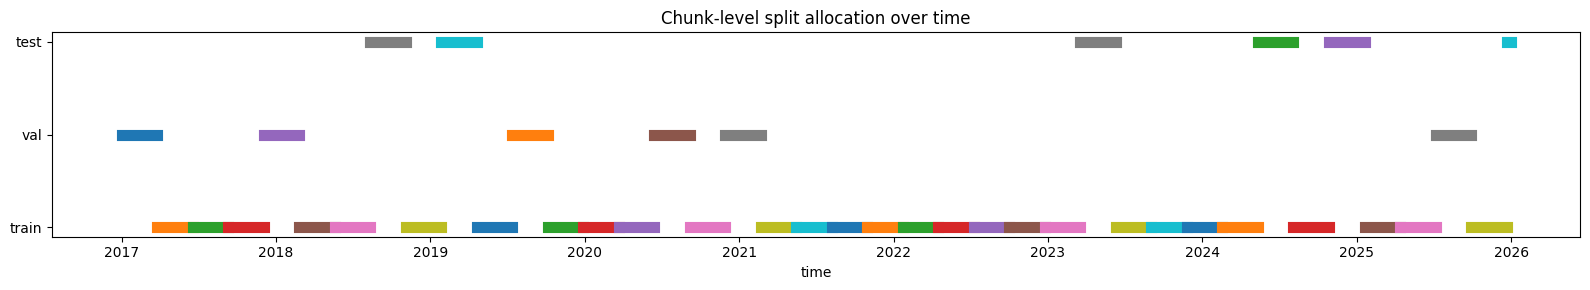

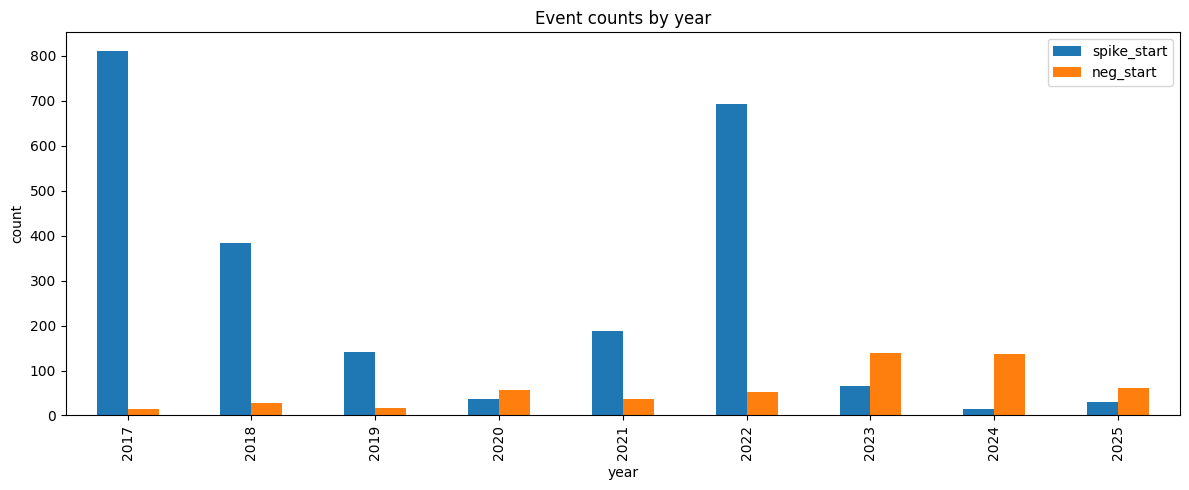

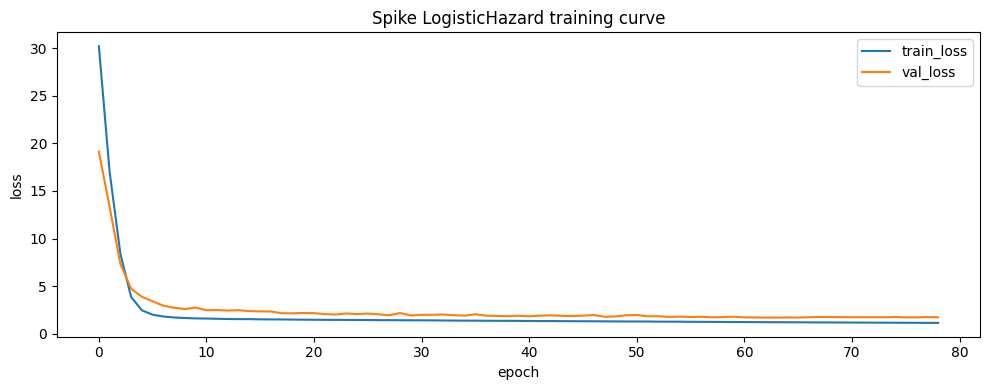

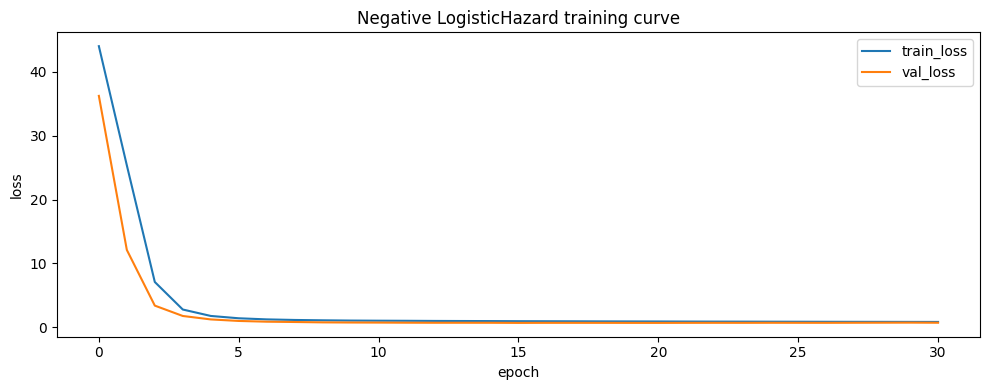

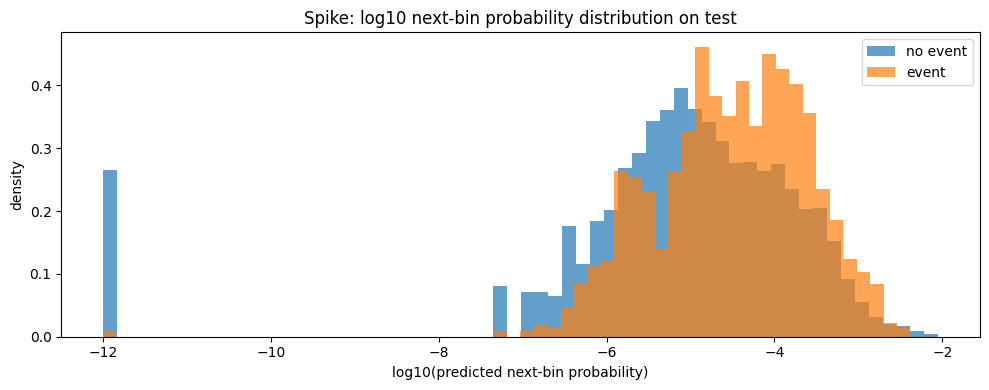

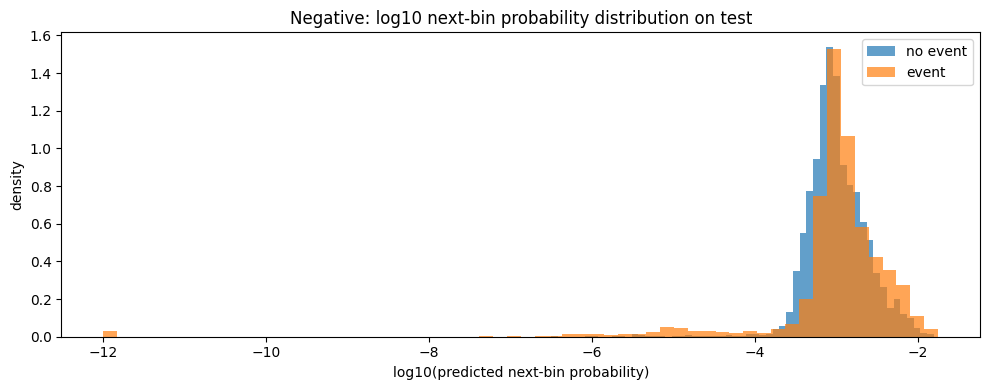

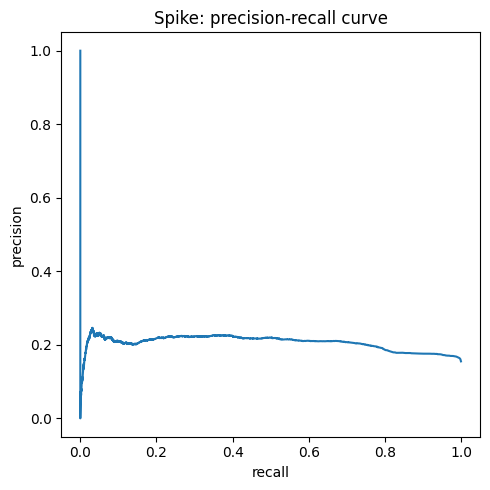

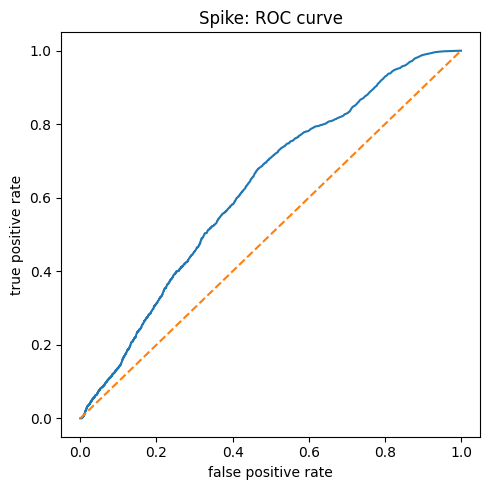

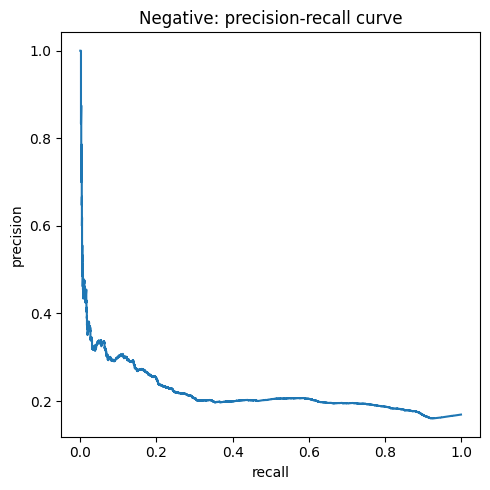

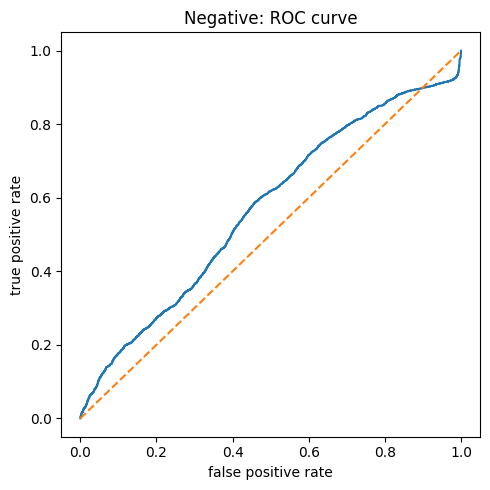

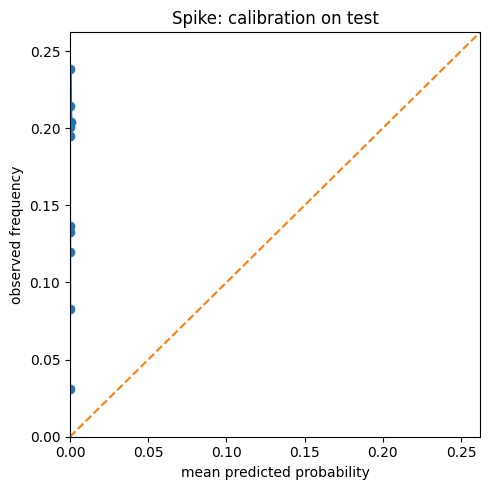

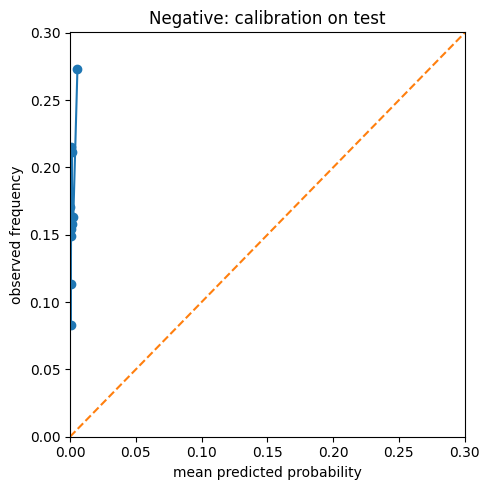

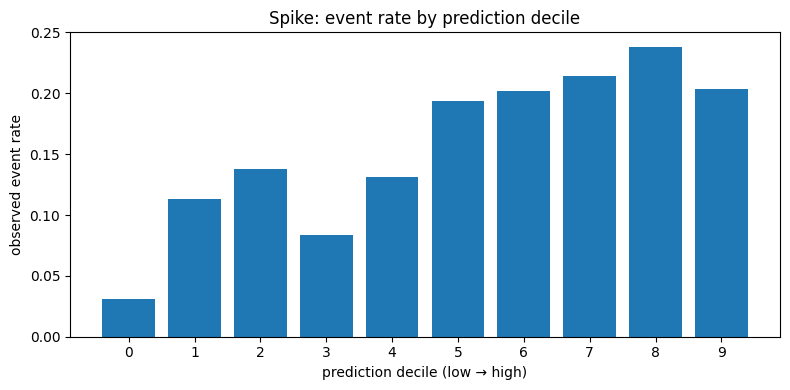

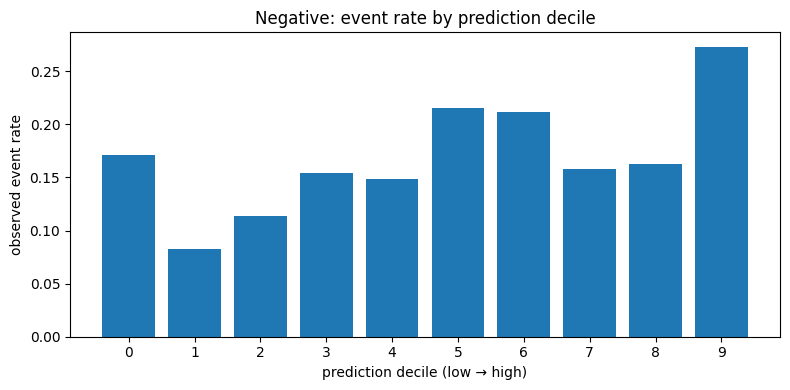

/tmp/ipykernel_4692/921846263.py:213: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda x: x["start_time"].dt.to_period("M").dt.to_timestamp())


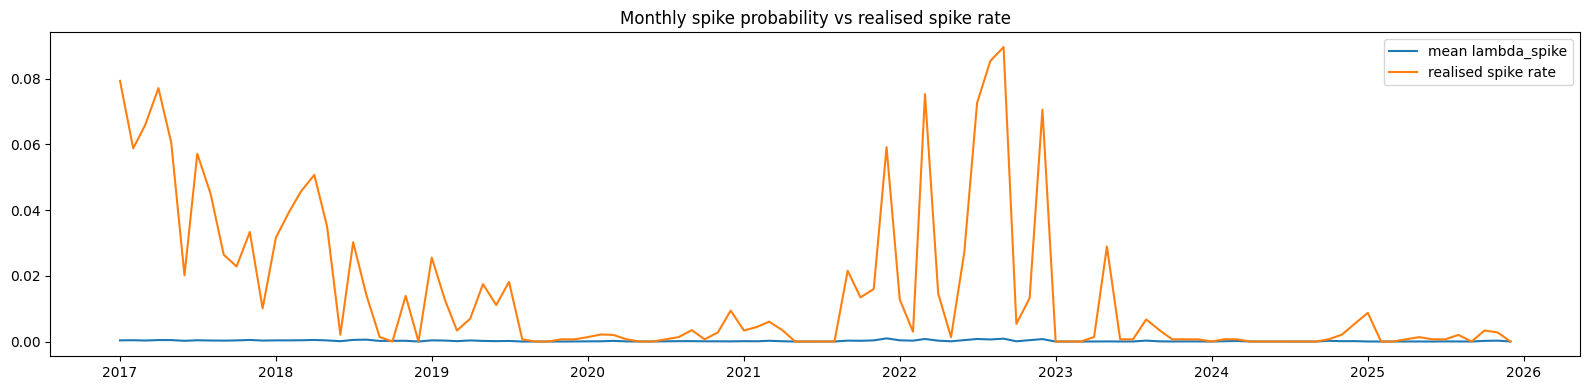

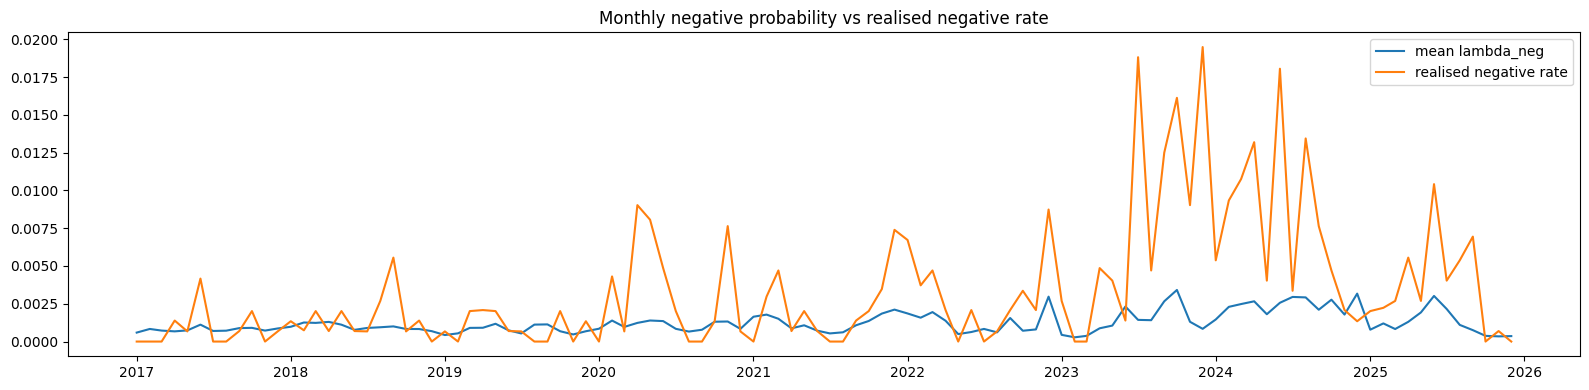

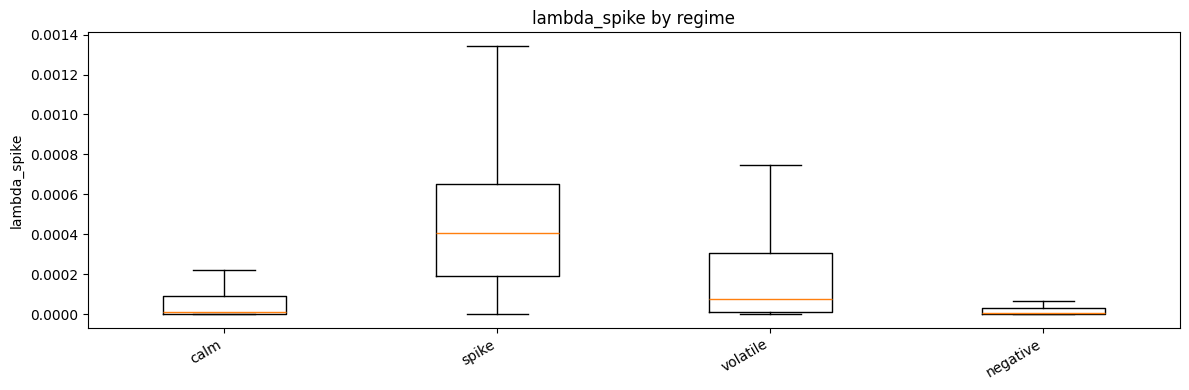

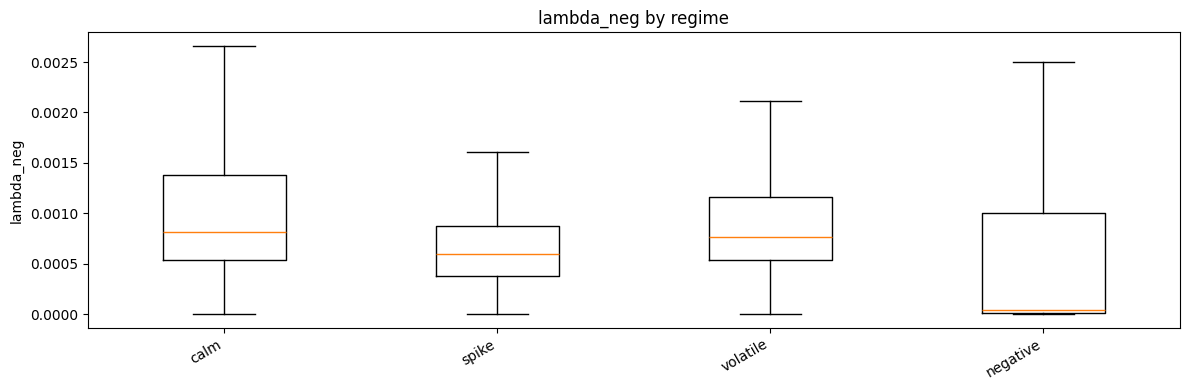

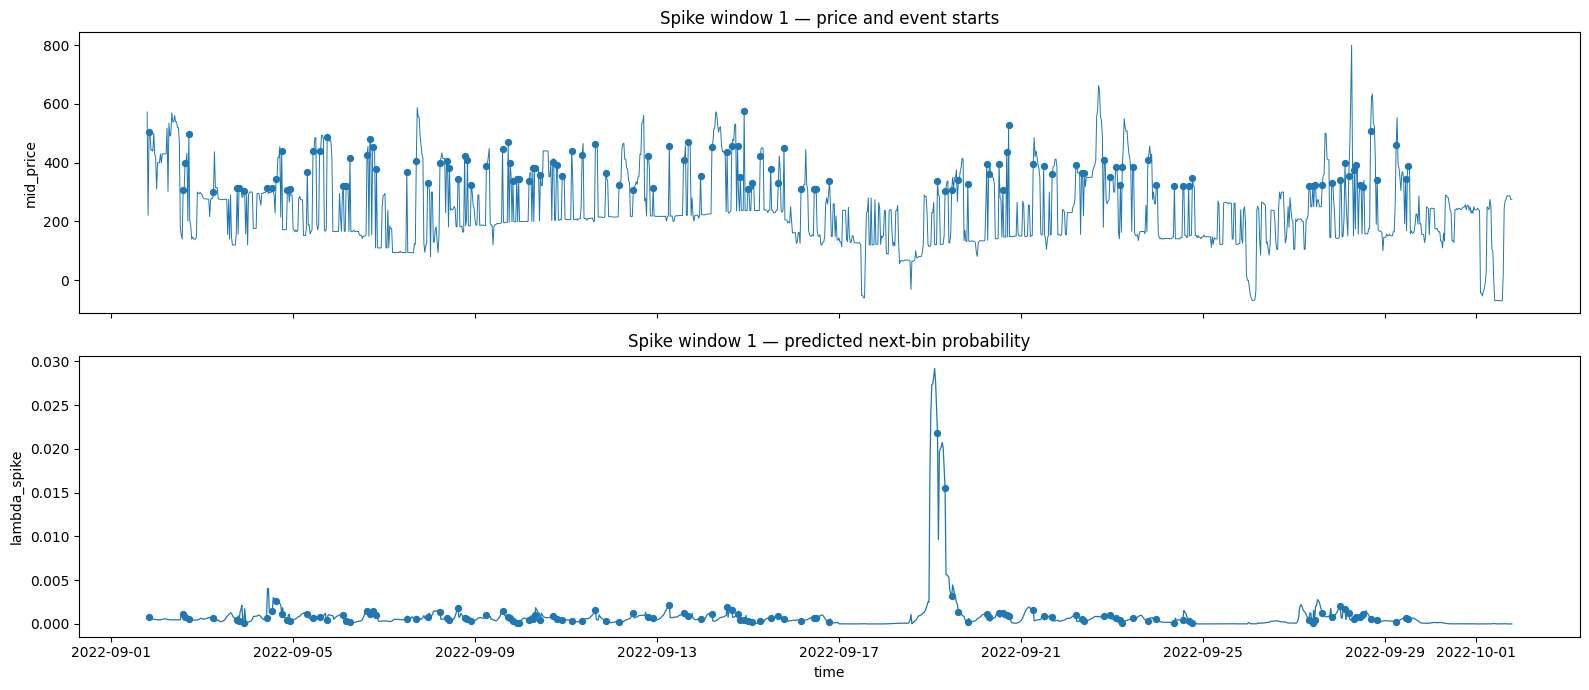

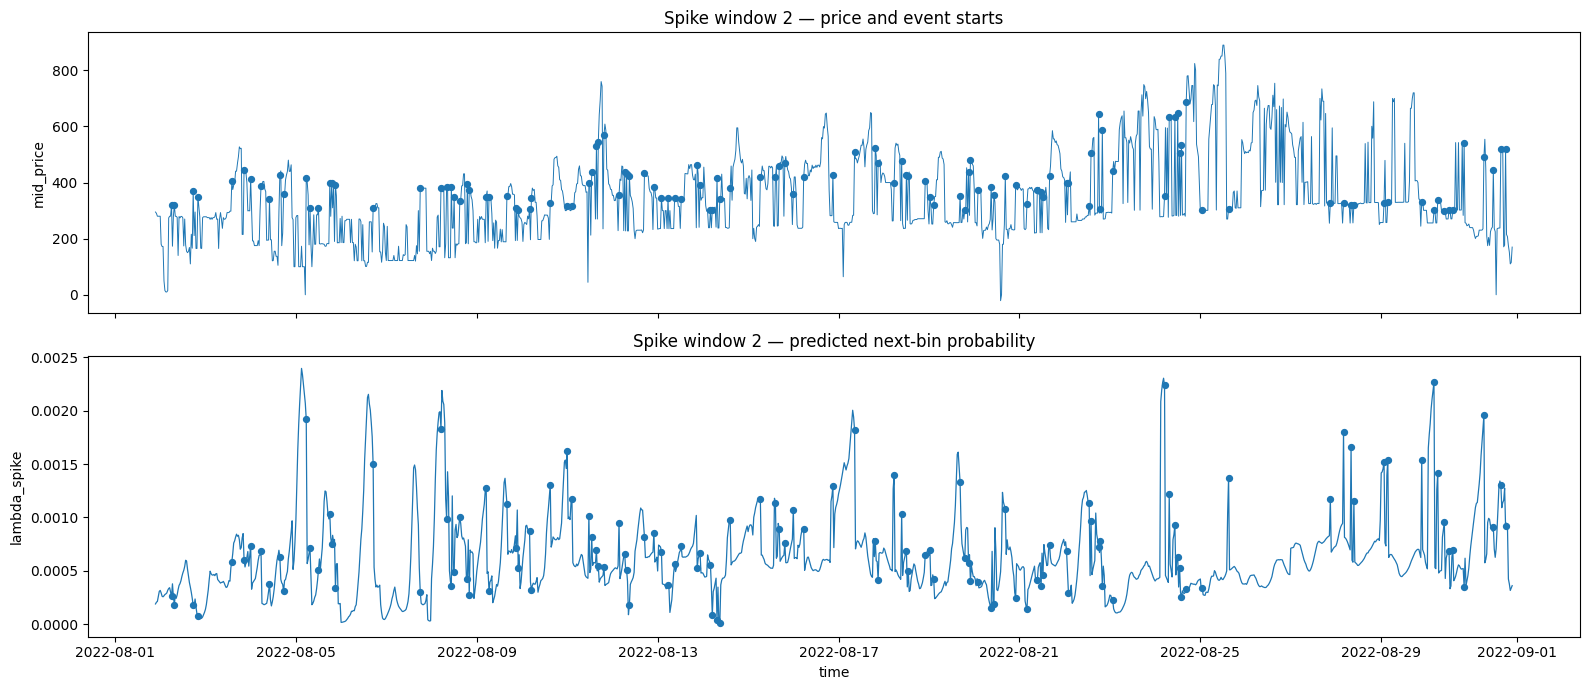

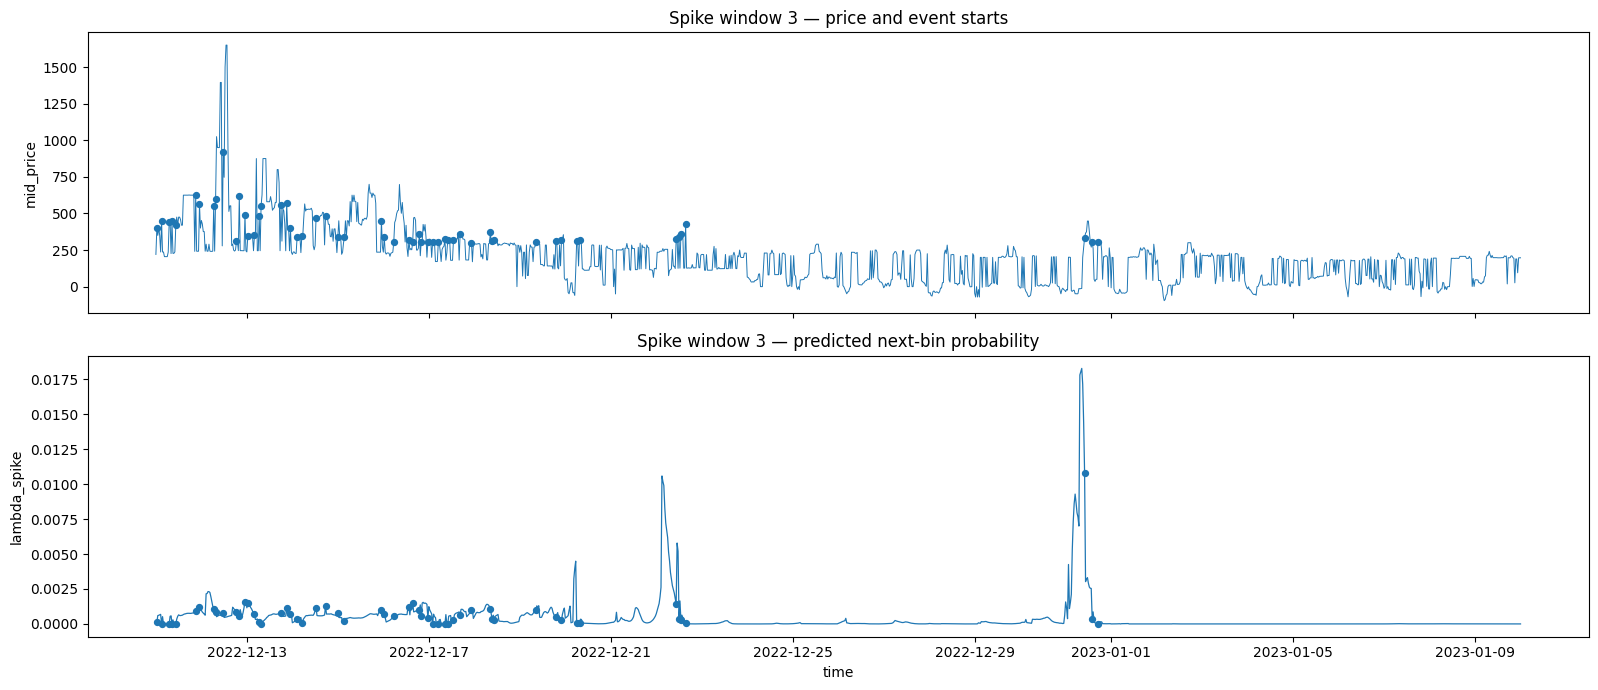

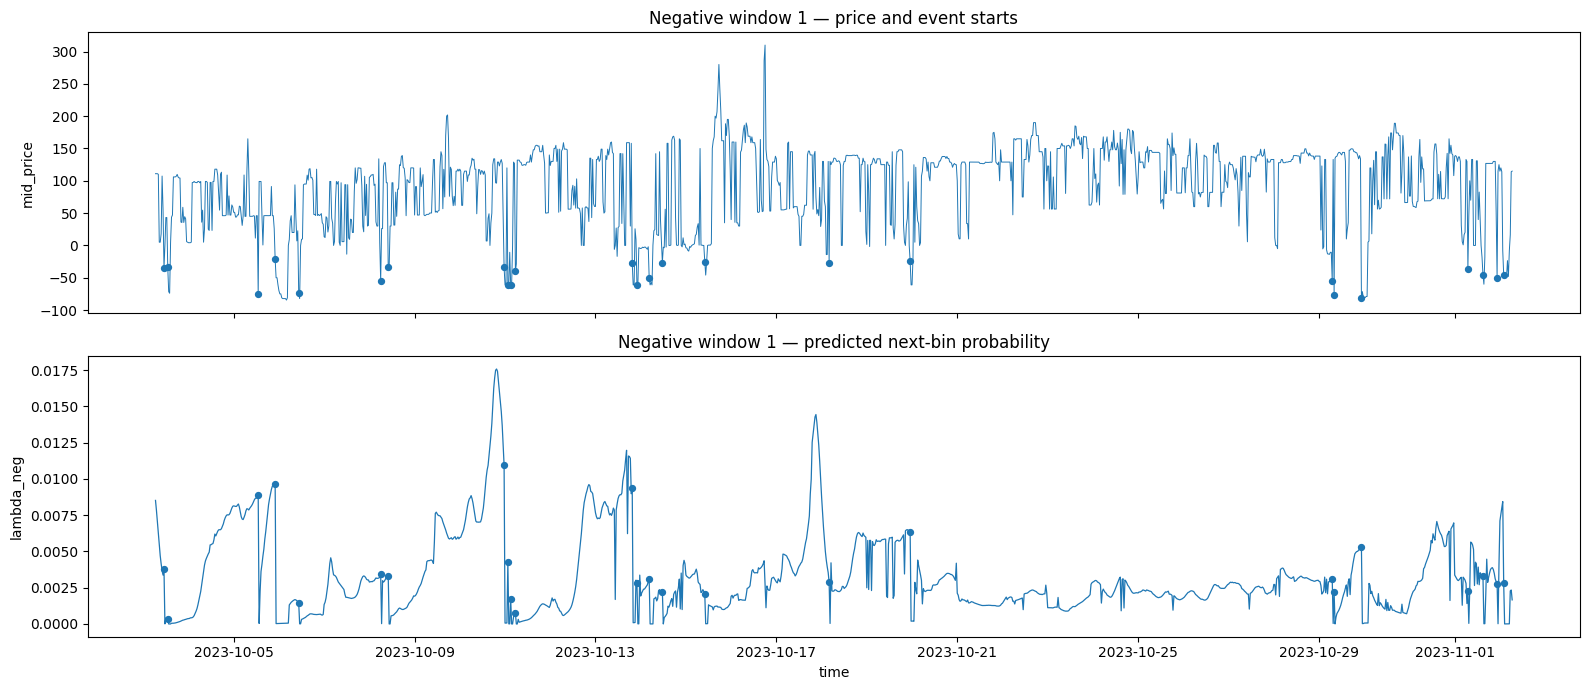

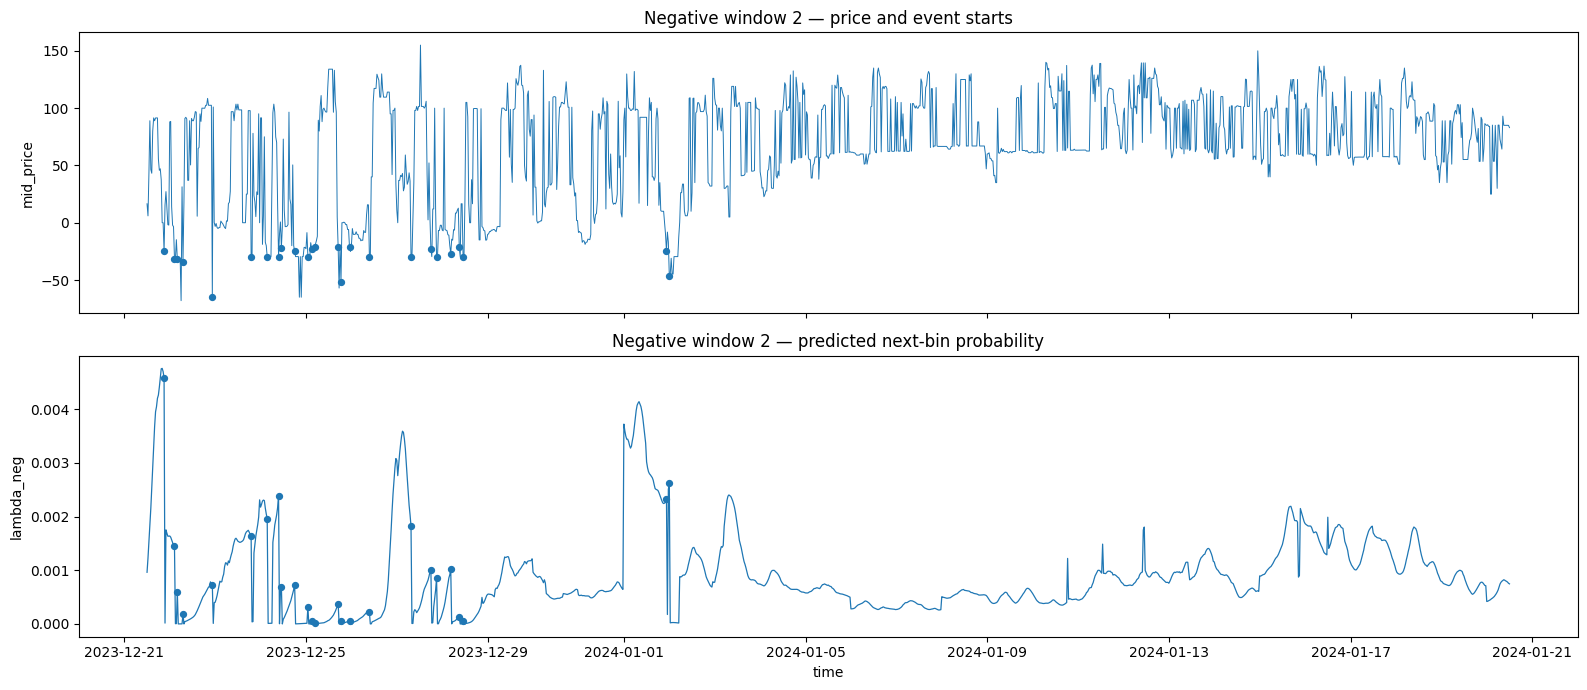

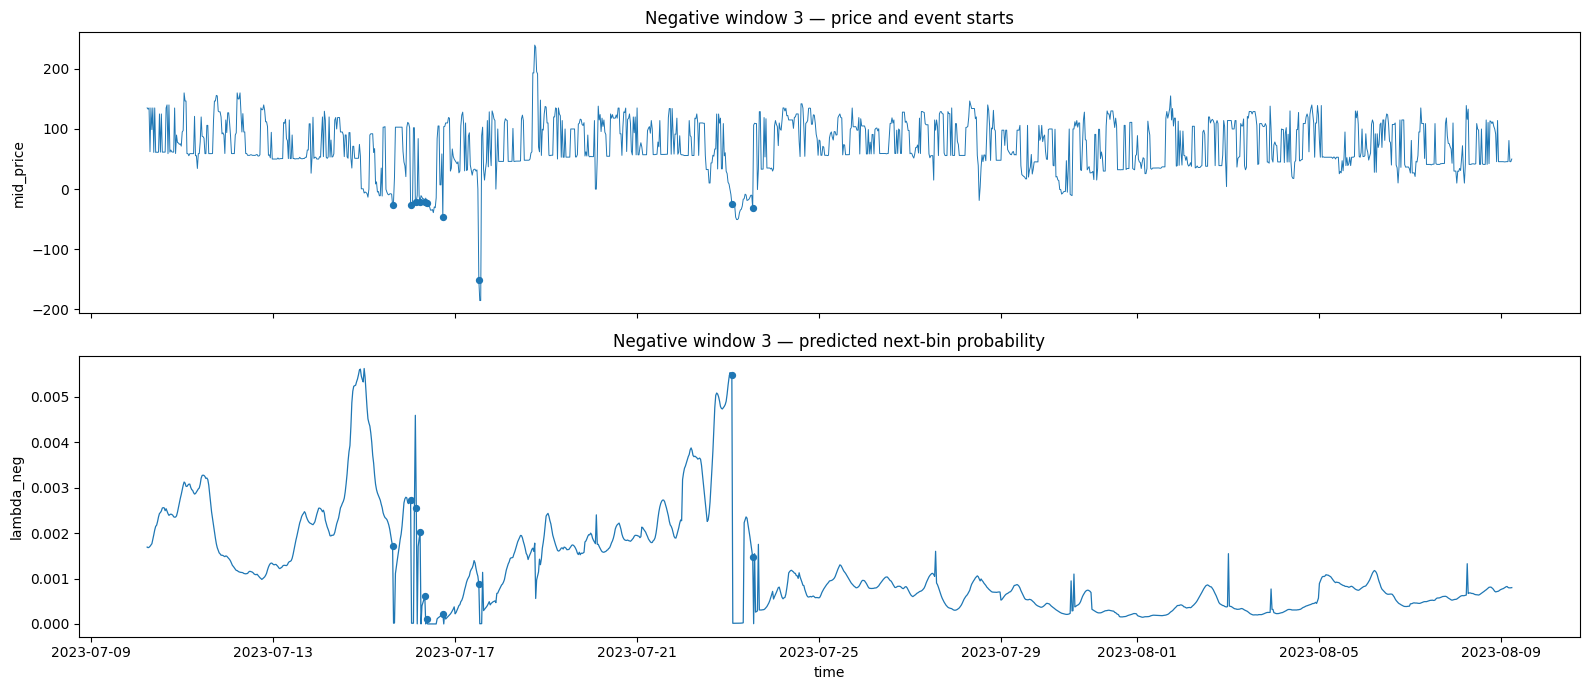

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — Diagnostics and visualisation
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, roc_curve

def plot_training_log(log_obj, title):
    try:
        log_df = log_obj.to_pandas()
    except Exception:
        print(f"Could not parse training log for {title}")
        return

    cols = list(log_df.columns)
    train_col = next((c for c in cols if "train_loss" in c.lower()), None)
    val_col   = next((c for c in cols if "val_loss" in c.lower()), None)

    fig, ax = plt.subplots(figsize=(10, 4))
    if train_col is not None:
        ax.plot(log_df[train_col].values, label="train_loss")
    if val_col is not None:
        ax.plot(log_df[val_col].values, label="val_loss")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_pr_roc(y_true, y_score, name):
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(rec, prec)
    ax.set_title(f"{name}: precision-recall curve")
    ax.set_xlabel("recall")
    ax.set_ylabel("precision")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr, tpr)
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_title(f"{name}: ROC curve")
    ax.set_xlabel("false positive rate")
    ax.set_ylabel("true positive rate")
    plt.tight_layout()
    plt.show()

def plot_calibration(y_true, y_score, name, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype=np.float64)

    mask = np.isfinite(y_score)
    y_true = y_true[mask]
    y_score = y_score[mask]
    y_score = np.clip(y_score, 0.0, 1.0)

    if len(y_score) == 0:
        print(f"{name}: no finite scores for calibration plot")
        return

    # If scores are almost constant, quantile binning can get silly.
    if np.unique(np.round(y_score, 12)).size < 3:
        print(f"{name}: scores are nearly constant; skipping calibration plot")
        return

    frac_pos, mean_pred = calibration_curve(
        y_true, y_score, n_bins=n_bins, strategy="quantile"
    )

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(mean_pred, frac_pos, marker="o")
    lim = max(
        float(np.max(mean_pred)) * 1.1 if len(mean_pred) else 0.0,
        float(np.max(frac_pos)) * 1.1 if len(frac_pos) else 0.0,
        1e-4,
    )
    ax.plot([0, lim], [0, lim], linestyle="--")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_title(f"{name}: calibration on test")
    ax.set_xlabel("mean predicted probability")
    ax.set_ylabel("observed frequency")
    plt.tight_layout()
    plt.show()


def plot_decile_lift(y_true, y_score, name):
    tmp = pd.DataFrame({"y": y_true, "score": y_score}).copy()
    tmp["decile"] = pd.qcut(tmp["score"].rank(method="first"), 10, labels=False)
    dec = tmp.groupby("decile").agg(
        mean_score=("score", "mean"),
        event_rate=("y", "mean"),
        n=("y", "size"),
    ).reset_index()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(dec["decile"].astype(str), dec["event_rate"])
    ax.set_title(f"{name}: event rate by prediction decile")
    ax.set_xlabel("prediction decile (low → high)")
    ax.set_ylabel("observed event rate")
    plt.tight_layout()
    plt.show()

def plot_log_hist(y_true, y_score, name):
    y_true = np.asarray(y_true).astype(bool)
    y_score = np.asarray(y_score, dtype=np.float64)
    y_score = np.nan_to_num(y_score, nan=0.0, posinf=1.0, neginf=0.0)
    y_score = np.clip(y_score, 0.0, 1.0)

    eps = 1e-12
    z0 = np.log10(np.maximum(y_score[~y_true], eps))
    z1 = np.log10(np.maximum(y_score[y_true], eps))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(z0, bins=60, alpha=0.7, density=True, label="no event")
    ax.hist(z1, bins=60, alpha=0.7, density=True, label="event")
    ax.set_title(f"{name}: log10 next-bin probability distribution on test")
    ax.set_xlabel("log10(predicted next-bin probability)")
    ax.set_ylabel("density")
    ax.legend()
    plt.tight_layout()
    plt.show()

def pick_top_windows(df_in, event_col, window_days=30, top_n=3, min_gap_days=20):
    s = df_in.set_index("start_time")[event_col].astype(float)
    rolling = s.rolling(f"{window_days}D").sum().dropna().sort_values(ascending=False)

    picks = []
    for ts, _ in rolling.items():
        if all(abs((ts - p).days) >= min_gap_days for p in picks):
            picks.append(ts)
        if len(picks) >= top_n:
            break
    return picks

def plot_time_window(df_in, center_time, lambda_col, event_col, title, days_before=15, days_after=15):
    lo = center_time - pd.Timedelta(days=days_before)
    hi = center_time + pd.Timedelta(days=days_after)
    sample = df_in[(df_in["start_time"] >= lo) & (df_in["start_time"] <= hi)].copy()
    sample = sample.dropna(subset=[lambda_col])

    ev = sample[sample[event_col]]

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

    axes[0].plot(sample["start_time"], sample["mid_price"], linewidth=0.7)
    axes[0].scatter(ev["start_time"], ev["mid_price"], s=18, zorder=3)
    axes[0].set_title(f"{title} — price and event starts")
    axes[0].set_ylabel("mid_price")

    axes[1].plot(sample["start_time"], sample[lambda_col], linewidth=0.9)
    axes[1].scatter(ev["start_time"], sample.loc[ev.index, lambda_col], s=18, zorder=3)
    axes[1].set_title(f"{title} — predicted next-bin probability")
    axes[1].set_ylabel(lambda_col)
    axes[1].set_xlabel("time")

    plt.tight_layout()
    plt.show()

# Split allocation
plot_chunks = chunk_summary.copy()
plot_chunks["y"] = plot_chunks["split_raw"].map({"train": 0, "val": 1, "test": 2})

fig, ax = plt.subplots(figsize=(16, 3))
for _, r in plot_chunks.iterrows():
    ax.plot([r["chunk_start"], r["chunk_end"]], [r["y"], r["y"]], linewidth=8)
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(["train", "val", "test"])
ax.set_title("Chunk-level split allocation over time")
ax.set_xlabel("time")
plt.tight_layout()
plt.show()

# Event counts by year
year_counts = (
    df.assign(year=df["start_time"].dt.year)
      .groupby("year")[["spike_start", "neg_start"]]
      .sum()
)

fig, ax = plt.subplots(figsize=(12, 5))
year_counts.plot(kind="bar", ax=ax)
ax.set_title("Event counts by year")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

# Training curves
plot_training_log(spike_fit["log"], "Spike LogisticHazard training curve")
plot_training_log(neg_fit["log"], "Negative LogisticHazard training curve")

# Ranking / calibration diagnostics
plot_log_hist(spike_fit["y_test_next"], spike_fit["lambda_test"], "Spike")
plot_log_hist(neg_fit["y_test_next"], neg_fit["lambda_test"], "Negative")

plot_pr_roc(spike_fit["y_test_next"], spike_fit["lambda_test"], "Spike")
plot_pr_roc(neg_fit["y_test_next"], neg_fit["lambda_test"], "Negative")

plot_calibration(spike_fit["y_test_next"], spike_fit["lambda_test"], "Spike")
plot_calibration(neg_fit["y_test_next"], neg_fit["lambda_test"], "Negative")

plot_decile_lift(spike_fit["y_test_next"], spike_fit["lambda_test"], "Spike")
plot_decile_lift(neg_fit["y_test_next"], neg_fit["lambda_test"], "Negative")

# Monthly lambda vs realised event rate
monthly = (
    df.dropna(subset=["lambda_spike", "lambda_neg"])
      .assign(month=lambda x: x["start_time"].dt.to_period("M").dt.to_timestamp())
      .groupby("month")
      .agg(
          lambda_spike_mean=("lambda_spike", "mean"),
          lambda_neg_mean=("lambda_neg", "mean"),
          spike_rate=("spike_start", "mean"),
          neg_rate=("neg_start", "mean"),
      )
      .reset_index()
)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(monthly["month"], monthly["lambda_spike_mean"], label="mean lambda_spike")
ax.plot(monthly["month"], monthly["spike_rate"], label="realised spike rate")
ax.set_title("Monthly spike probability vs realised spike rate")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(monthly["month"], monthly["lambda_neg_mean"], label="mean lambda_neg")
ax.plot(monthly["month"], monthly["neg_rate"], label="realised negative rate")
ax.set_title("Monthly negative probability vs realised negative rate")
ax.legend()
plt.tight_layout()
plt.show()

# Lambda by regime
regime_col_for_plot = "regime_refined" if "regime_refined" in df.columns else "regime"
top_regimes = df[regime_col_for_plot].value_counts().head(8).index.tolist()

for lam_col in ["lambda_spike", "lambda_neg"]:
    data = [
        df.loc[df[regime_col_for_plot] == reg, lam_col].dropna().to_numpy()
        for reg in top_regimes
    ]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.boxplot(data, tick_labels=top_regimes, showfliers=False)
    ax.set_title(f"{lam_col} by {regime_col_for_plot}")
    ax.set_ylabel(lam_col)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# Event-rich windows
spike_windows = pick_top_windows(df.dropna(subset=["lambda_spike"]), "spike_start", window_days=30, top_n=3)
neg_windows = pick_top_windows(df.dropna(subset=["lambda_neg"]), "neg_start", window_days=30, top_n=3)

for i, ts in enumerate(spike_windows, 1):
    plot_time_window(
        df, center_time=ts, lambda_col="lambda_spike", event_col="spike_start",
        title=f"Spike window {i}", days_before=15, days_after=15
    )

for i, ts in enumerate(neg_windows, 1):
    plot_time_window(
        df, center_time=ts, lambda_col="lambda_neg", event_col="neg_start",
        title=f"Negative window {i}", days_before=15, days_after=15
    )

## Optuna param search


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL — Optuna tuning on GPU for LogisticHazard
# ═══════════════════════════════════════════════════════════════════════════

%pip install -q optuna

import random
import numpy as np
import torch
import torchtuples as tt
import optuna

from pycox.models import LogisticHazard
from sklearn.metrics import average_precision_score, roc_auc_score

# -------------------------------------------------------------------------
# Guards
# -------------------------------------------------------------------------
required_globals = [
    "DEVICE",
    "X_train_t", "X_val_t", "X_test_t", "X_all_t",
    "y_train_spike_t", "y_val_spike_t",
    "y_train_neg_t", "y_val_neg_t",
    "y_val_next_spike", "y_val_next_neg",
    "labtrans_spike", "labtrans_neg",
]
missing = [x for x in required_globals if x not in globals()]
assert not missing, f"Missing required objects before GPU Optuna cell: {missing}"

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

# -------------------------------------------------------------------------
# Helpers
# -------------------------------------------------------------------------
def safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if np.unique(y_true).size < 2:
        return 0.5
    return roc_auc_score(y_true, y_score)

def next_bin_probability(model, X_t):
    """
    LogisticHazard next-bin probability = 1 - survival after first interval.
    Returns a clean numpy array in [0,1].
    """
    with torch.no_grad():
        surv = model.predict_surv_df(X_t)
    p = 1.0 - surv.iloc[0].to_numpy(dtype=np.float64)
    p = np.nan_to_num(p, nan=0.0, posinf=1.0, neginf=0.0)
    p = np.clip(p, 0.0, 1.0)
    return p

def make_trial_net(trial, in_features, out_features):
    n_layers = trial.suggest_int("n_layers", 2, 4)
    width = trial.suggest_categorical("width", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.25)
    batch_norm = trial.suggest_categorical("batch_norm", [True, False])

    net = tt.practical.MLPVanilla(
        in_features=in_features,
        num_nodes=[width] * n_layers,
        out_features=out_features,
        batch_norm=batch_norm,
        dropout=dropout,
        activation=torch.nn.ReLU,
        output_bias=False,
    ).to(DEVICE)
    return net

def tune_loghazard_gpu(
    name,
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t,
    y_val_next,
    out_features,
    n_trials=25,
    seed=42,
):
    """
    Tune a single LogisticHazard model on GPU.
    Objective = 0.8 * AP + 0.2 * AUC on validation next-bin event prediction.
    """
    y_val_next = np.asarray(y_val_next).astype(int)

    def objective(trial):
        # Search space
        lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [512, 1024, 2048, 4096])
        epochs = trial.suggest_int("epochs", 60, 140)
        patience = trial.suggest_int("patience", 8, 20)

        net = make_trial_net(trial, X_train_t.shape[1], out_features)
        optimizer = tt.optim.Adam(lr=lr, weight_decay=weight_decay)
        model = LogisticHazard(net, optimizer)
        model.net.to(DEVICE)

        callbacks = [tt.callbacks.EarlyStopping(patience=patience)]

        log = model.fit(
            X_train_t,
            y_train_t,
            batch_size=batch_size,
            epochs=epochs,
            callbacks=callbacks,
            verbose=False,
            val_data=(X_val_t, y_val_t),
        )

        lambda_val = next_bin_probability(model, X_val_t)

        ap = average_precision_score(y_val_next, lambda_val)
        auc = safe_roc_auc(y_val_next, lambda_val)
        score = 0.80 * ap + 0.20 * auc

        trial.set_user_attr("val_ap", float(ap))
        trial.set_user_attr("val_auc", float(auc))
        trial.set_user_attr("epochs_run", int(len(log.to_pandas())))

        # Free a bit of memory between trials
        del model, net
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        return score

    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print(f"\nBest {name} params:")
    print(study.best_params)
    print(f"Best {name} score:   {study.best_value:.6f}")
    print(f"Best {name} val AP:  {study.best_trial.user_attrs['val_ap']:.6f}")
    print(f"Best {name} val AUC: {study.best_trial.user_attrs['val_auc']:.6f}")
    print(f"Best {name} epochs actually run: {study.best_trial.user_attrs['epochs_run']}")

    return study

# -------------------------------------------------------------------------
# Run studies
# -------------------------------------------------------------------------
spike_study = tune_loghazard_gpu(
    name="Spike",
    X_train_t=X_train_t,
    y_train_t=y_train_spike_t,
    X_val_t=X_val_t,
    y_val_t=y_val_spike_t,
    y_val_next=y_val_next_spike,
    out_features=labtrans_spike.out_features,
    n_trials=25,
    seed=GLOBAL_SEED,
)

neg_study = tune_loghazard_gpu(
    name="Negative",
    X_train_t=X_train_t,
    y_train_t=y_train_neg_t,
    X_val_t=X_val_t,
    y_val_t=y_val_neg_t,
    y_val_next=y_val_next_neg,
    out_features=labtrans_neg.out_features,
    n_trials=25,
    seed=GLOBAL_SEED + 1,
)

[I 2026-04-13 22:05:40,895] A new study created in memory with name: no-name-65ab1cfe-17c0-47ec-8b4d-d5d5349cadad


[I 2026-04-13 22:06:16,465] Trial 0 finished with value: 0.7962426556271441 and parameters: {'lr': 0.0003574712922600243, 'weight_decay': 0.0006351221010640698, 'batch_size': 512, 'epochs': 64, 'patience': 19, 'n_layers': 3, 'width': 256, 'dropout': 0.20811066020010544, 'batch_norm': True}. Best is trial 0 with value: 0.7962426556271441.
[I 2026-04-13 22:06:28,878] Trial 1 finished with value: 0.6554200568126367 and parameters: {'lr': 0.00018659959624904942, 'weight_decay': 1.6480446427978977e-06, 'batch_size': 4096, 'epochs': 71, 'patience': 11, 'n_layers': 3, 'width': 128, 'dropout': 0.1285586096034029, 'batch_norm': True}. Best is trial 0 with value: 0.7962426556271441.
[I 2026-04-13 22:06:34,628] Trial 2 finished with value: 0.4060675171530068 and parameters: {'lr': 0.0007896186801026692, 'weight_decay': 4.809461967501569e-07, 'batch_size': 2048, 'epochs': 84, 'patience': 9, 'n_layers': 4, 'width': 256, 'dropout': 0.008597130278804599, 'batch_norm': True}. Best is trial 0 with valu

[I 2026-04-13 22:13:25,175] A new study created in memory with name: no-name-9f8cbc52-28c1-4795-a616-40f389deb0a4


[I 2026-04-13 22:13:25,171] Trial 24 finished with value: 0.8943466224680772 and parameters: {'lr': 0.0005907380110568289, 'weight_decay': 0.0001357299895988127, 'batch_size': 2048, 'epochs': 132, 'patience': 11, 'n_layers': 2, 'width': 64, 'dropout': 0.06745047113535327, 'batch_norm': False}. Best is trial 11 with value: 0.928231581599094.

Best Spike params:
{'lr': 0.002951490161620501, 'weight_decay': 0.0009486881566591943, 'batch_size': 2048, 'epochs': 137, 'patience': 15, 'n_layers': 2, 'width': 64, 'dropout': 0.0796453901951627, 'batch_norm': False}
Best Spike score:   0.928232
Best Spike val AP:  0.924495
Best Spike val AUC: 0.943177
Best Spike epochs actually run: 49


[I 2026-04-13 22:13:35,443] Trial 0 finished with value: 0.3396479561649828 and parameters: {'lr': 0.00014789365614666463, 'weight_decay': 2.7306507478234025e-05, 'batch_size': 4096, 'epochs': 113, 'patience': 15, 'n_layers': 2, 'width': 256, 'dropout': 0.06360528146496983, 'batch_norm': False}. Best is trial 0 with value: 0.3396479561649828.
[I 2026-04-13 22:14:01,870] Trial 1 finished with value: 0.26611505042032424 and parameters: {'lr': 0.00021207360929467574, 'weight_decay': 4.168288711224154e-06, 'batch_size': 4096, 'epochs': 138, 'patience': 13, 'n_layers': 4, 'width': 128, 'dropout': 0.22427464499538358, 'batch_norm': True}. Best is trial 0 with value: 0.3396479561649828.
[I 2026-04-13 22:14:32,642] Trial 2 finished with value: 0.21470711467083672 and parameters: {'lr': 0.00010175996898797494, 'weight_decay': 1.488709847421564e-05, 'batch_size': 2048, 'epochs': 133, 'patience': 14, 'n_layers': 2, 'width': 128, 'dropout': 0.21625428015179543, 'batch_norm': True}. Best is trial 0

In [24]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL — Refit final spike/negative models from Optuna best params on GPU
# ═══════════════════════════════════════════════════════════════════════════

spike_fit = fit_logistic_hazard_model(
    name="Spike",
    X_train_t=X_train_t,
    y_train_t=y_train_spike_t,
    X_val_t=X_val_t,
    y_val_t=y_val_spike_t,
    X_test_t=X_test_t,
    X_all_t=X_all_t,
    y_val_next=y_val_next_spike,
    y_test_next=y_test_next_spike,
    out_features=labtrans_spike.out_features,
    width=spike_study.best_params["width"],
    n_layers=spike_study.best_params["n_layers"],
    dropout=spike_study.best_params["dropout"],
    batch_norm=spike_study.best_params["batch_norm"],
    lr=spike_study.best_params["lr"],
    weight_decay=spike_study.best_params["weight_decay"],
    batch_size=spike_study.best_params["batch_size"],
    epochs=spike_study.best_params["epochs"],
    patience=spike_study.best_params["patience"],
)

neg_fit = fit_logistic_hazard_model(
    name="Negative",
    X_train_t=X_train_t,
    y_train_t=y_train_neg_t,
    X_val_t=X_val_t,
    y_val_t=y_val_neg_t,
    X_test_t=X_test_t,
    X_all_t=X_all_t,
    y_val_next=y_val_next_neg,
    y_test_next=y_test_next_neg,
    out_features=labtrans_neg.out_features,
    width=neg_study.best_params["width"],
    n_layers=neg_study.best_params["n_layers"],
    dropout=neg_study.best_params["dropout"],
    batch_norm=neg_study.best_params["batch_norm"],
    lr=neg_study.best_params["lr"],
    weight_decay=neg_study.best_params["weight_decay"],
    batch_size=neg_study.best_params["batch_size"],
    epochs=neg_study.best_params["epochs"],
    patience=neg_study.best_params["patience"],
)


Training Spike LogisticHazard on cuda...
0:	[0s / 0s],		train_loss: 7.4833,	val_loss: 1.8012
1:	[0s / 0s],		train_loss: 1.6370,	val_loss: 1.5986
2:	[0s / 0s],		train_loss: 1.5678,	val_loss: 1.5601
3:	[0s / 0s],		train_loss: 1.5448,	val_loss: 1.5457
4:	[0s / 1s],		train_loss: 1.5296,	val_loss: 1.5357
5:	[0s / 1s],		train_loss: 1.5202,	val_loss: 1.5282
6:	[0s / 1s],		train_loss: 1.5070,	val_loss: 1.5206
7:	[0s / 1s],		train_loss: 1.4981,	val_loss: 1.5143
8:	[0s / 1s],		train_loss: 1.4887,	val_loss: 1.5063
9:	[0s / 2s],		train_loss: 1.4816,	val_loss: 1.5008
10:	[0s / 2s],		train_loss: 1.4715,	val_loss: 1.4930
11:	[0s / 2s],		train_loss: 1.4651,	val_loss: 1.4853
12:	[0s / 2s],		train_loss: 1.4566,	val_loss: 1.4797
13:	[0s / 2s],		train_loss: 1.4476,	val_loss: 1.4725
14:	[0s / 3s],		train_loss: 1.4421,	val_loss: 1.4673
15:	[0s / 3s],		train_loss: 1.4330,	val_loss: 1.4624
16:	[0s / 3s],		train_loss: 1.4270,	val_loss: 1.4578
17:	[0s / 3s],		train_loss: 1.4230,	val_loss: 1.4529
18:	[0s / 3s],

In [25]:
import torchtuples as tt
from pycox.models import LogisticHazard
from sklearn.metrics import average_precision_score, roc_auc_score

def safe_roc_auc(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    if np.unique(y_true).size < 2:
        return 0.5
    return roc_auc_score(y_true, y_score)

def next_bin_probability(model, X_t):
    with torch.no_grad():
        surv = model.predict_surv_df(X_t)
    p = 1.0 - surv.iloc[0].to_numpy(dtype=np.float64)
    p = np.nan_to_num(p, nan=0.0, posinf=1.0, neginf=0.0)
    p = np.clip(p, 0.0, 1.0)
    return p

def fit_logistic_hazard_model(
    name,
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t,
    X_test_t,
    X_all_t,
    y_val_next,
    y_test_next,
    out_features,
    width=128,
    n_layers=3,
    dropout=0.10,
    batch_norm=True,
    lr=1e-3,
    weight_decay=1e-5,
    batch_size=2048,
    epochs=120,
    patience=15,
):
    num_nodes = [width] * n_layers

    net = tt.practical.MLPVanilla(
        in_features=X_train_t.shape[1],
        num_nodes=num_nodes,
        out_features=out_features,
        batch_norm=batch_norm,
        dropout=dropout,
        activation=torch.nn.ReLU,
        output_bias=False,
    ).to(DEVICE)

    optimizer = tt.optim.Adam(lr=lr, weight_decay=weight_decay)
    model = LogisticHazard(net, optimizer)
    model.net.to(DEVICE)

    callbacks = [tt.callbacks.EarlyStopping(patience=patience)]

    print(f"\nTraining {name} LogisticHazard on {DEVICE}...")
    log = model.fit(
        X_train_t,
        y_train_t,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        verbose=True,
        val_data=(X_val_t, y_val_t),
    )

    lambda_val = next_bin_probability(model, X_val_t)
    lambda_test = next_bin_probability(model, X_test_t)
    lambda_all = next_bin_probability(model, X_all_t)

    metrics = {
        "val_average_precision": float(average_precision_score(y_val_next, lambda_val)),
        "val_roc_auc": float(safe_roc_auc(y_val_next, lambda_val)),
        "test_positive_rate": float(np.mean(y_test_next)),
        "test_average_precision": float(average_precision_score(y_test_next, lambda_test)),
        "test_roc_auc": float(safe_roc_auc(y_test_next, lambda_test)),
    }

    print(f"\n{name} metrics:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.6f}")

    return {
        "model": model,
        "log": log,
        "lambda_val": lambda_val,
        "lambda_test": lambda_test,
        "lambda_all": lambda_all,
        "y_val_next": np.asarray(y_val_next).astype(int),
        "y_test_next": np.asarray(y_test_next).astype(int),
        "metrics": metrics,
        "params": {
            "width": width,
            "n_layers": n_layers,
            "dropout": dropout,
            "batch_norm": batch_norm,
            "lr": lr,
            "weight_decay": weight_decay,
            "batch_size": batch_size,
            "epochs": epochs,
            "patience": patience,
            "device": str(DEVICE),
        },
    }

## Train two separate LogisticHazard models

## Build half-hourly λ trajectories on the full master grid

In [26]:
# For the final HORIZON rows we cannot form a full training target, but we can still
# score features and predict λ_t on the current row.

X_full_raw = df[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
X_full_filled = X_full_raw.fillna(train_medians).fillna(0.0)
X_full_scaled = scaler.transform(X_full_filled)

lambda_spike_full = spike_fit["model"].predict_hazard(X_full_scaled.astype("float32"), numpy=True)[:, 0]
lambda_neg_full = neg_fit["model"].predict_hazard(X_full_scaled.astype("float32"), numpy=True)[:, 0]

df["lambda_spike"] = lambda_spike_full
df["lambda_neg"] = lambda_neg_full

print("\nHalf-hourly λ summaries (interpreted as next-bin event probabilities):")
print(f"  λ_spike: mean={df['lambda_spike'].mean():.6f}, max={df['lambda_spike'].max():.6f}")
print(f"  λ_neg:   mean={df['lambda_neg'].mean():.6f}, max={df['lambda_neg'].max():.6f}")


Half-hourly λ summaries (interpreted as next-bin event probabilities):
  λ_spike: mean=0.000239, max=0.022298
  λ_neg:   mean=0.000577, max=0.053388


## Aggregate to segment level for downstream conditioning

In [27]:
lam_spike_arr = df["lambda_spike"].to_numpy()
lam_neg_arr = df["lambda_neg"].to_numpy()

seg_records = []
for _, row in seg.iterrows():
    s, e = int(row["start_idx"]), int(row["end_idx"])
    seg_records.append({
        "start_idx": s,
        "end_idx": e,
        "seg_lambda_spike_mean": float(lam_spike_arr[s:e].mean()),
        "seg_lambda_neg_mean": float(lam_neg_arr[s:e].mean()),
        "seg_lambda_spike_max": float(lam_spike_arr[s:e].max()),
    })

seg_hazard = pd.DataFrame(seg_records)

print("\nPer-segment hazard features:")
print(seg_hazard[["seg_lambda_spike_mean", "seg_lambda_neg_mean", "seg_lambda_spike_max"]].describe())


Per-segment hazard features:
       seg_lambda_spike_mean  seg_lambda_neg_mean  seg_lambda_spike_max
count           6.530000e+03         6.530000e+03          6.530000e+03
mean            2.402098e-04         5.805458e-04          6.085463e-04
std             7.068300e-04         1.437430e-03          1.750737e-03
min             2.906919e-11         7.503127e-07          7.349756e-11
25%             3.169399e-08         4.573167e-05          9.244865e-08
50%             5.166616e-07         1.384044e-04          1.621901e-06
75%             5.450030e-05         4.058284e-04          1.994964e-04
max             9.280430e-03         1.993007e-02          2.229805e-02


## Save `hazard_features.parquet`, `hazard_features_seg.parquet`, and `hazard_fit.json`

In [28]:
halfhourly_out = df[["start_time", "lambda_spike", "lambda_neg"]].copy()
pl.from_pandas(halfhourly_out).write_parquet(DATA_DIR / "hazard_features.parquet")
print(f"Saved hazard_features.parquet: {len(halfhourly_out):,} rows")

pl.from_pandas(seg_hazard).write_parquet(DATA_DIR / "hazard_features_seg.parquet")
print(f"Saved hazard_features_seg.parquet: {len(seg_hazard):,} rows")

fit_json = {
    "model": "TwoLogisticHazardDiscreteTime",
    "prediction_grid": "30m",
    "lambda_definition": "next-bin event probability on the half-hour grid",
    "targets": ["spike_start", "neg_start"],
    "horizon_halfhours": HORIZON,
    "split_policy": {
        "type": "chronological_blocked_with_embargo",
        "train_frac": TRAIN_FRAC,
        "val_frac": VAL_FRAC,
        "test_frac": TEST_FRAC,
        "embargo_bins": EMBARGO_BINS,
        "train_range": [
            str(model_df.loc[train_mask, "start_time"].min()),
            str(model_df.loc[train_mask, "start_time"].max()),
        ],
        "val_range": [
            str(model_df.loc[val_mask, "start_time"].min()),
            str(model_df.loc[val_mask, "start_time"].max()),
        ],
        "test_range": [
            str(model_df.loc[test_mask, "start_time"].min()),
            str(model_df.loc[test_mask, "start_time"].max()),
        ],
    },
    "covid_kept": KEEP_COVID,
    "winning_label_scheme_for_downstream_segments": SIG_REGIME_COL,
    "feature_columns": feature_cols,
    "econometric_scalar_columns": econ_cols,
    "regime_feature_columns_master_grid": regime_cols,
    "event_memory_columns": event_memory_cols,
    "time_control_columns": time_cols + year_cols,
    "network": {
        "hidden_layers": HIDDEN,
        "dropout": DROPOUT,
        "batch_norm": True,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "seed": SEED,
    },
    "n_rows_master": int(len(df)),
    "n_rows_trainable": int(len(model_df)),
    "n_events_spike": int(df["spike_start"].sum()),
    "n_events_neg": int(df["neg_start"].sum()),
    "spike_metrics": spike_fit["metrics"],
    "neg_metrics": neg_fit["metrics"],
}
with open(DATA_DIR / "hazard_fit.json", "w") as fp:
    json.dump(fit_json, fp, indent=2)
print("Saved hazard_fit.json")

Saved hazard_features.parquet: 157,776 rows
Saved hazard_features_seg.parquet: 6,530 rows
Saved hazard_fit.json


## Sanity plots

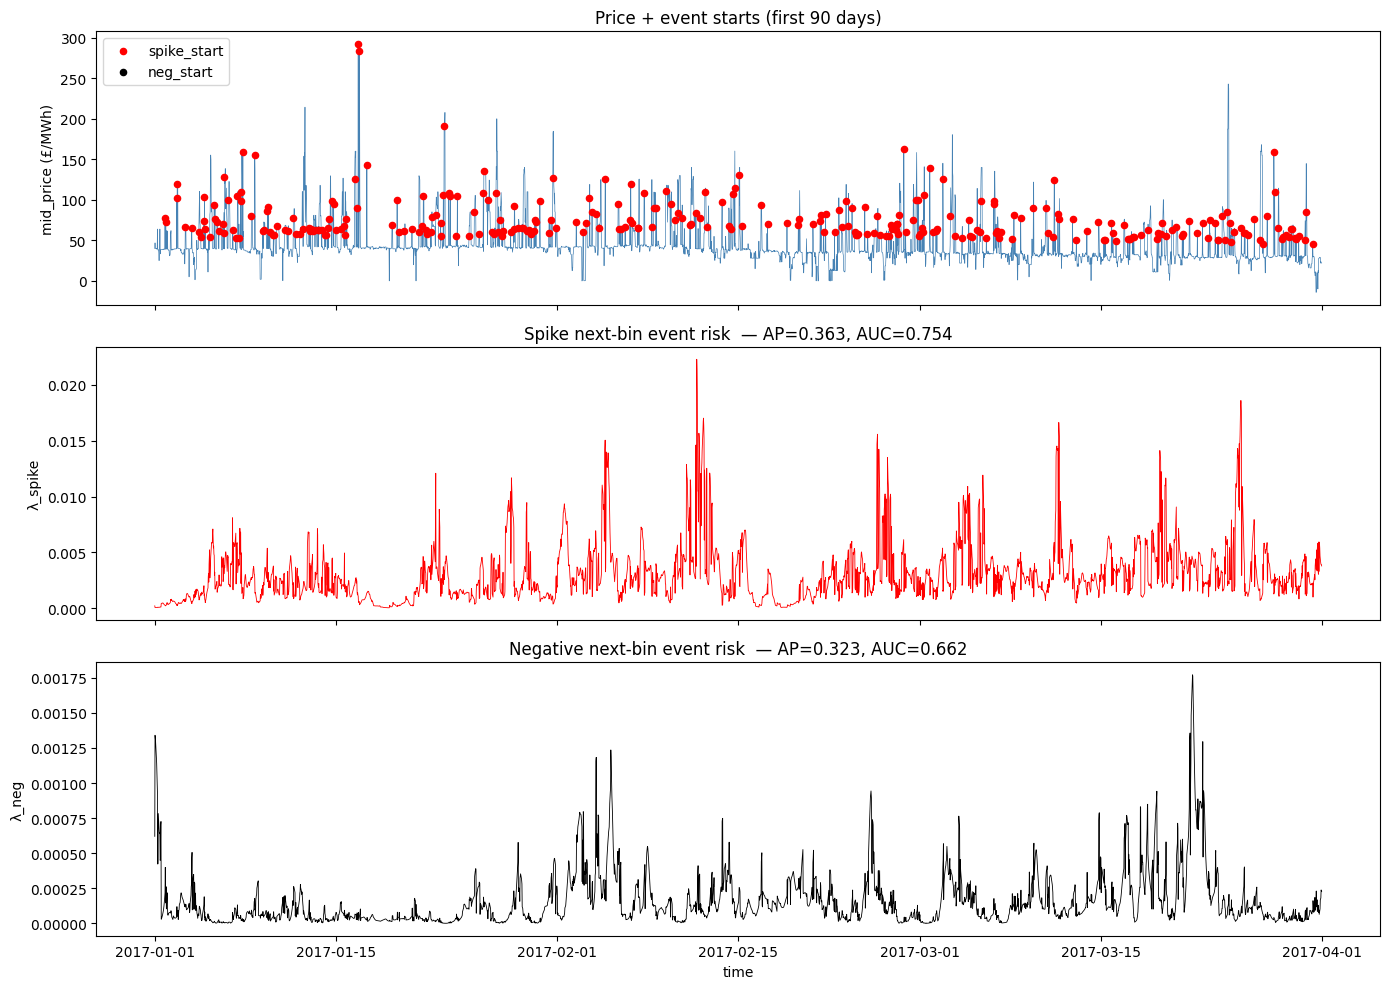


Notebook 02b complete.
Outputs:
  hazard_features.parquet      — half-hourly λ trajectories
  hazard_features_seg.parquet  — per-segment aggregates
  hazard_fit.json              — model metadata + held-out diagnostics
Downstream segment regime block: regime_refined


In [29]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

sample = df.iloc[: 48 * 90]  # first 90 days for visibility

# (a) Price with event starts overlaid
ax = axes[0]
ax.plot(sample["start_time"], sample["mid_price"], lw=0.5, color="steelblue")
sp = sample[sample["spike_start"]]
ng = sample[sample["neg_start"]]
ax.scatter(sp["start_time"], sp["mid_price"], color="red", s=20, label="spike_start", zorder=3)
ax.scatter(ng["start_time"], ng["mid_price"], color="black", s=20, label="neg_start", zorder=3)
ax.set_ylabel("mid_price (£/MWh)")
ax.legend(loc="upper left")
ax.set_title("Price + event starts (first 90 days)")

# (b) λ_spike trajectory
ax = axes[1]
ax.plot(sample["start_time"], sample["lambda_spike"], color="red", lw=0.6)
ax.set_ylabel("λ_spike")
ax.set_title(
    "Spike next-bin event risk  — "
    f"AP={spike_fit['metrics']['test_average_precision']:.3f}, "
    f"AUC={spike_fit['metrics']['test_roc_auc']:.3f}"
)

# (c) λ_neg trajectory
ax = axes[2]
ax.plot(sample["start_time"], sample["lambda_neg"], color="black", lw=0.6)
ax.set_ylabel("λ_neg")
ax.set_xlabel("time")
ax.set_title(
    "Negative next-bin event risk  — "
    f"AP={neg_fit['metrics']['test_average_precision']:.3f}, "
    f"AUC={neg_fit['metrics']['test_roc_auc']:.3f}"
)

plt.tight_layout()
plt.savefig(FIG_DIR / "02b_hazard_trajectories.png", dpi=120, bbox_inches="tight")
plt.show()

print("\n" + "=" * 70)
print("Notebook 02b complete.")
print("=" * 70)
print("Outputs:")
print("  hazard_features.parquet      — half-hourly λ trajectories")
print("  hazard_features_seg.parquet  — per-segment aggregates")
print("  hazard_fit.json              — model metadata + held-out diagnostics")
print(f"Downstream segment regime block: {SIG_REGIME_COL}")